# 01 — Exploratory Data Analysis

**Project:** Football Betting Integrity Monitor
**Author:** Vladislav Kivaev
**Last updated:** June 2026

---

## Overview

Exploratory data analysis of betting odds across four European football leagues — German Bundesliga (D1), English Premier League (E0), Turkish Süper Lig (T1), and Greek Super League (G1) — for the seasons 2019/20 through 2025/26.

The goal of this notebook is to:
1. Inspect and audit the raw data downloaded from football-data.co.uk
2. Clean and merge it into a single analytical dataset
3. Engineer odds-based features (drift, spread, overround)
4. Explore market structure, bookmaker accuracy, and odds movement to test four hypotheses:

- **H1** — Mid-tier leagues (Turkey, Greece) are less efficiently priced than elite leagues (Bundesliga, EPL)
- **H2** — Draws are systematically mispriced in specific leagues
- **H3** — Anomalous matches can be identified from odds features (tested in modeling phase)
- **H4** — Bookmaker disagreement concentrates toward the end of the season

The cleaned outputs (`master.csv` and `master_enriched.csv`) feed the feature engineering and modeling notebooks.

## Glossary — Betting Market Terms

**Odds**
The price a bookmaker offers on an outcome. In decimal format (used throughout this project), odds of 2.50 mean you receive €2.50 for every €1 bet — €1.50 profit plus your €1 stake back. Higher odds = less likely outcome in the bookmaker's view.



**Implied Probability**
The bookmaker's estimate of how likely an outcome is, derived directly from the odds: `1 / odds`. Odds of 2.50 imply a 40% chance (1/2.50 = 0.40). This is their "true" assessment before margin is added.



**Overround (Bookmaker Margin)**
If you add up the implied probabilities of all three outcomes (home win + draw + away win), they should equal 100% in a fair market. Bookmakers always price them above 100% — the excess is their profit margin, called the overround. An overround of 1.06 means the bookmaker has built in a 6% margin regardless of the result. Also called the "vig" or "juice" in some markets.



**Opening Odds**
The price a bookmaker sets at the start of the betting market for a match — typically several days before kickoff. This is the bookmaker's initial assessment before the market has been tested by bettors.



**Closing Odds**
The final price just before kickoff, after the full betting period has elapsed and all market activity has influenced the line. Closing odds are considered the most informationally efficient prices — they reflect everything the market has learned.



**Drift**
The movement in odds from opening to closing price: `closing odds − opening odds`. A positive drift means odds got longer (outcome became less likely in the market's view). A negative drift means odds shortened (outcome became more likely). Large drift in either direction indicates significant information arrived during the betting window.



**Pinnacle Drift**
Drift specifically measured using Pinnacle's odds. Because Pinnacle accepts sharp bettors and large stakes (unlike most bookmakers who limit or ban winners), their line movements are driven by genuinely informed money. Pinnacle drift is therefore the cleanest signal of whether professional or informed bettors moved on a match.



**Sharp Money**
Bets placed by professional or highly informed bettors (called "sharps") who consistently beat the market. When sharp money enters, bookmakers move their lines in response. Pinnacle's odds reflect sharp money more than any other bookmaker because they actively welcome it.



**Spread (Bookmaker Spread)**
The gap between the best available odds across all bookmakers (Max) and the market average (Avg): `Max − Avg`. A wide spread means bookmakers disagree significantly on the true price of an outcome. A narrow spread means they converge — a more efficient market. In this project, spread is the primary measure of market efficiency.



**Max Odds**
The highest odds available for an outcome across all bookmakers at a given time. Represents the market ceiling — the most optimistic price any bookmaker is willing to offer.



**Average Odds**
The average odds across all bookmakers for a given outcome. Represents market consensus — what a typical bookmaker thinks the price should be.



**Closing Spread**
The bookmaker spread computed at closing odds: `MaxCH − AvgCH`. Measures disagreement at the final market state, just before kickoff. Compared to opening spread, it shows whether the market converged or diverged over the betting window.



**Spread Change**
The difference between closing spread and opening spread: `closing spread − opening spread`. A positive value means bookmakers disagreed *more* at close than at open — unusual, since efficient markets should converge. A negative value means they converged — normal market behaviour.



**B365 vs Market Gap**
How far Bet365's closing odds sit below the market ceiling: `MaxCH − B365CH`. A large gap means Bet365 is offering a significantly worse price than the best available — a signal that Bet365 is being conservative on a specific match.



**Normalised Implied Probability**
Raw implied probabilities include the bookmaker margin and sum to more than 100%. Normalising divides each outcome's implied probability by the total, scaling them back to sum to exactly 100%. This gives the bookmaker's true probability estimate with the margin removed — used for calibration and bias analysis.



**Calibration**
A measure of how accurately bookmaker odds predict actual outcomes. A perfectly calibrated bookmaker means: every time they price an outcome at 60% implied probability, it actually occurs 60% of the time. Deviations reveal systematic mispricing.



**Favourite-Longshot Bias (FLB)**
A well-documented market phenomenon where longshots (high-odds outcomes) are systematically overpriced relative to their true probability, while strong favourites are underpriced. In practice: betting longshots is a worse deal than the odds suggest, and backing heavy favourites returns slightly better than implied. Stronger FLB = less efficient market.



**Closing Line Value (CLV)**
Whether a bet placed at opening odds beats the closing price. If you back a team at 3.00 opening and Pinnacle closes at 2.50, you got "value" — the market moved in your direction, suggesting your information was correct. Sharp bettors consistently achieve positive CLV. Used as a quality signal for betting information.



**Draw Mispricing**
The gap between the market's implied draw probability and the actual draw frequency: `realised draw rate − implied draw probability`. A persistently positive value means draws happen more often than the market expects — the bookmaker systematically underestimates draw probability. Integrity-relevant because draws are the classic match-fixing vehicle: both clubs can benefit from an arranged draw.

## 1. Data Inspection

Inspect the raw CSV files before any cleaning — file counts, row counts, and column availability across leagues and seasons.

In [1]:
import pandas as pd
from pathlib import Path

RAW_DIR = Path('../data/raw')

# Load all CSV file paths keyed by filename stem (e.g. 'D1_1718')
raw_files = sorted(RAW_DIR.glob('*.csv'))
print(f"Found {len(raw_files)} CSV files")

Found 36 CSV files


### 1.1 File count and row counts per league/season

In [2]:
rows_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f)
    rows_data.append({'league': league, 'season': season, 'matches': len(df)})

rows_df = pd.DataFrame(rows_data)
pivot = rows_df.pivot(index='season', columns='league', values='matches')
print(pivot.to_string())

league   D1   E0   G1   T1
season                    
1718    306  380  240  306
1819    306  380  240  306
1920    306  380  240  306
2021    306  380  240  420
2122    306  380  240  380
2223    306  380  240  342
2324    306  380  240  380
2425    306  380  233  342
2526    306  380  236  306


### 1.2 Column schema audit (column counts by season)

In [3]:
schema_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    schema_data.append({
        'league': league,
        'season': season,
        'n_columns': len(df.columns),
    })

schema_df = pd.DataFrame(schema_data)

# Column counts per league per season
pivot_schema = schema_df.pivot(index='season', columns='league', values='n_columns')
print("Column counts per league/season:")
print(pivot_schema.to_string())

Column counts per league/season:
league   D1   E0   G1   T1
season                    
1718     64   65   64   64
1819     61   62   61   61
1920    105  106  105  105
2021    105  106  105  105
2122    105  106  105  105
2223    105  106  105  105
2324    105  106  105  105
2425    119  120  119  119
2526    131  132  131  131


### 1.3 Core column availability (15-column check)

Check whether the original 15 core columns (match info + opening B365/Max/Avg odds) are present in every file.

In [4]:
CORE_COLS_BASIC = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'B365H', 'B365D', 'B365A',
    'MaxH', 'MaxD', 'MaxA',
    'AvgH', 'AvgD', 'AvgA'
]

print("Core column availability across all files:\n")
missing_any = False

for f in sorted(raw_files):
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    missing = [c for c in CORE_COLS_BASIC if c not in df.columns]
    if missing:
        print(f"  MISSING in {league}_{season}: {missing}")
        missing_any = True

if not missing_any:
    print("  All 15 core columns present in all files")

Core column availability across all files:

  MISSING in D1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in D1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']


### 1.4 Extended column audit (closing odds + Pinnacle)

Verify that closing odds and Pinnacle columns exist across all files for the 7 seasons we intend to use.

In [5]:
SEASONS_TO_USE = ["1920", "2021", "2122", "2223", "2324", "2425", "2526"]

OPENING_COLS = ['B365H', 'B365D', 'B365A']
CLOSING_COLS = ['B365CH', 'B365CD', 'B365CA',
                'MaxCH', 'MaxCD', 'MaxCA',
                'AvgCH', 'AvgCD', 'AvgCA']
PINNACLE_COLS = ['PSH', 'PSD', 'PSA',       # opening
                 'PSCH', 'PSCD', 'PSCA']    # closing

ALL_CHECK_COLS = OPENING_COLS + CLOSING_COLS + PINNACLE_COLS

results = []
for f in sorted(RAW_DIR.glob('*.csv')):
    league, season = f.stem.split('_')
    if season not in SEASONS_TO_USE:
        continue
    df = pd.read_csv(f, nrows=5)
    row = {'league': league, 'season': season}
    for col in ALL_CHECK_COLS:
        row[col] = 'Y' if col in df.columns else 'N'
    results.append(row)

audit_df = pd.DataFrame(results)

for league in ['D1', 'E0', 'T1', 'G1']:
    print(f"\n{'='*60}")
    print(f"  {league}")
    print(f"{'='*60}")
    sub = audit_df[audit_df['league'] == league].set_index('season').drop(columns='league')
    print(sub.to_string())


  D1
       B365H B365D B365A B365CH B365CD B365CA MaxCH MaxCD MaxCA AvgCH AvgCD AvgCA PSH PSD PSA PSCH PSCD PSCA
season                                                                                                      
1920       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2021       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2122       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2223       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2324       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2425       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y
2526       Y     Y     Y      Y      Y      Y     Y     Y     Y     Y     Y     Y   Y   Y   Y    Y    Y    Y

  E0
       

> **Note:** Seasons 2017/18 and 2018/19 are excluded from all downstream analysis because they are missing the Max and Average odds columns, which are central to the spread and overround features. We work with the 7 complete seasons from 2019/20 to 2025/26.

## 2. Data Cleaning & Merging

Load the 7 usable seasons across all 4 leagues, select the columns we need, add metadata, audit for nulls and errors, and engineer odds-based features.

### 2.1 Load and merge (33 core columns, 7 seasons, 4 leagues)

Select 30 odds columns (opening + closing for B365, Pinnacle, Max, Avg) plus match info, and add league / season / tier metadata.

In [6]:
CORE_COLS = [
    # Match info
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    # B365 opening / closing
    'B365H', 'B365D', 'B365A',
    'B365CH', 'B365CD', 'B365CA',
    # Pinnacle opening / closing
    'PSH', 'PSD', 'PSA',
    'PSCH', 'PSCD', 'PSCA',
    # Market max opening / closing
    'MaxH', 'MaxD', 'MaxA',
    'MaxCH', 'MaxCD', 'MaxCA',
    # Market avg opening / closing
    'AvgH', 'AvgD', 'AvgA',
    'AvgCH', 'AvgCD', 'AvgCA',
]

TIER_MAP = {'D1': 'elite', 'E0': 'elite', 'T1': 'mid_tier', 'G1': 'mid_tier'}
SEASONS_TO_USE = ["1920", "2021", "2122", "2223", "2324", "2425", "2526"]

frames = []
for f in sorted(RAW_DIR.glob('*.csv')):
    league, season = f.stem.split('_')
    if season not in SEASONS_TO_USE:
        continue
    df = pd.read_csv(f, usecols=CORE_COLS)
    df['league'] = league
    df['season'] = season
    df['tier'] = TIER_MAP[league]
    frames.append(df)

master = pd.concat(frames, ignore_index=True)

print(f"Total rows:    {len(master):,}")
print(f"Total columns: {len(master.columns)}")
print(f"\nLeague counts:\n{master['league'].value_counts()}")
print(f"\nTier counts:\n{master['tier'].value_counts()}")

Total rows:    8,947
Total columns: 33

League counts:
league
E0    2660
T1    2476
D1    2142
G1    1669
Name: count, dtype: int64

Tier counts:
tier
elite       4802
mid_tier    4145
Name: count, dtype: int64


### 2.2 Fix data types

In [7]:
master['Date'] = pd.to_datetime(master['Date'], dayfirst=True)
master['FTHG'] = master['FTHG'].astype('Int64')
master['FTAG'] = master['FTAG'].astype('Int64')

odds_cols = [c for c in master.columns if c not in
             ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'league', 'season', 'tier', 'FTHG', 'FTAG']]
for col in odds_cols:
    master[col] = pd.to_numeric(master[col], errors='coerce')

print(master.dtypes)
print(f"\nDate range: {master['Date'].min().date()} -> {master['Date'].max().date()}")

Date        datetime64[us]
HomeTeam               str
AwayTeam               str
FTHG                 Int64
FTAG                 Int64
FTR                    str
B365H              float64
B365D              float64
B365A              float64
PSH                float64
PSD                float64
PSA                float64
MaxH               float64
MaxD               float64
MaxA               float64
AvgH               float64
AvgD               float64
AvgA               float64
B365CH             float64
B365CD             float64
B365CA             float64
PSCH               float64
PSCD               float64
PSCA               float64
MaxCH              float64
MaxCD              float64
MaxCA              float64
AvgCH              float64
AvgCD              float64
AvgCA              float64
league                 str
season                 str
tier                   str
dtype: object

Date range: 2019-08-09 -> 2026-05-24


### 2.3 Null audit

In [8]:
print("=== Null counts (non-zero only) ===")
nulls = master.isnull().sum()
print(nulls[nulls > 0])
print(f"\nTotal rows: {len(master):,}")

=== Null counts (non-zero only) ===
B365H      56
B365D      56
B365A      56
PSH       756
PSD       756
PSA       756
MaxH       30
MaxD       30
MaxA       30
AvgH       30
AvgD       30
AvgA       30
B365CH     29
B365CD     29
B365CA     29
PSCH      709
PSCD      709
PSCA      709
MaxCH      29
MaxCD      29
MaxCA      29
AvgCH      29
AvgCD      29
AvgCA      29
dtype: int64

Total rows: 8,947


### 2.4 Drop unrecoverable rows (closing odds missing)

Rows missing closing Max/Avg odds have no usable odds data for our primary features, so they are dropped.

In [9]:
before = len(master)
master = master.dropna(subset=['MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA'])
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")
print(f"\nRemaining nulls:")
nulls = master.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "None")

Rows dropped: 29
Rows remaining: 8,918

Remaining nulls:
B365H     27
B365D     27
B365A     27
PSH      727
PSD      727
PSA      727
MaxH       1
MaxD       1
MaxA       1
AvgH       1
AvgD       1
AvgA       1
PSCH     680
PSCD     680
PSCA     680
dtype: int64


### 2.5 Pinnacle null distribution

Pinnacle has more missing data than B365. Check where the gaps are concentrated before deciding how to handle them.

In [10]:
print("=== Pinnacle null distribution ===\n")

psc_nulls = master[master['PSCH'].isnull()].groupby(['league','season']).size()
print("Pinnacle CLOSING nulls by league/season:")
print(psc_nulls)

print(f"\nTotal Pinnacle closing nulls: {master['PSCH'].isnull().sum()}")
print(f"As % of dataset: {master['PSCH'].isnull().sum()/len(master)*100:.1f}%")

both_null = master[master['PSCH'].isnull() & master['B365CH'].isnull()]
print(f"\nRows missing BOTH Pinnacle and B365 closing: {len(both_null)}")
print(f"Rows missing Pinnacle only: {master['PSCH'].isnull().sum() - len(both_null)}")

=== Pinnacle null distribution ===

Pinnacle CLOSING nulls by league/season:
league  season
D1      2526      157
E0      2526      170
G1      2526      181
T1      2122        1
        2526      171
dtype: int64

Total Pinnacle closing nulls: 680
As % of dataset: 7.6%

Rows missing BOTH Pinnacle and B365 closing: 0
Rows missing Pinnacle only: 680


> **Note:** Pinnacle closing odds are missing for ~50% of the 2025/26 season across all leagues. This is a football-data.co.uk upload lag (data cuts off ~January 2026), not a coverage gap. Pinnacle features are kept and used where available, with NaN handled downstream. The gap is documented as a limitation.

### 2.6 Compute derived features

Engineer all odds-based features in one place: drift (closing − opening), spread (Max − Avg), spread change, B365 vs market gap, and implied probability sums.

In [11]:
# --- Drift (closing - opening) ---
master['b365_drift_H'] = master['B365CH'] - master['B365H']
master['b365_drift_D'] = master['B365CD'] - master['B365D']
master['b365_drift_A'] = master['B365CA'] - master['B365A']

master['pinnacle_drift_H'] = master['PSCH'] - master['PSH']
master['pinnacle_drift_D'] = master['PSCD'] - master['PSD']
master['pinnacle_drift_A'] = master['PSCA'] - master['PSA']

# --- Spread (Max - Avg), opening and closing ---
master['opening_spread_H'] = master['MaxH'] - master['AvgH']
master['opening_spread_D'] = master['MaxD'] - master['AvgD']
master['opening_spread_A'] = master['MaxA'] - master['AvgA']

master['closing_spread_H'] = master['MaxCH'] - master['AvgCH']
master['closing_spread_D'] = master['MaxCD'] - master['AvgCD']
master['closing_spread_A'] = master['MaxCA'] - master['AvgCA']

master['max_opening_spread'] = master[['opening_spread_H','opening_spread_D','opening_spread_A']].max(axis=1)
master['max_closing_spread'] = master[['closing_spread_H','closing_spread_D','closing_spread_A']].max(axis=1)

# --- Spread change (closing - opening spread) ---
master['spread_change_H'] = master['closing_spread_H'] - master['opening_spread_H']
master['spread_change_D'] = master['closing_spread_D'] - master['opening_spread_D']
master['spread_change_A'] = master['closing_spread_A'] - master['opening_spread_A']
master['max_spread_change'] = master[['spread_change_H','spread_change_D','spread_change_A']].max(axis=1)

# --- B365 vs market gap (closing) ---
master['b365_vs_market_H'] = master['MaxCH'] - master['B365CH']
master['b365_vs_market_D'] = master['MaxCD'] - master['B365CD']
master['b365_vs_market_A'] = master['MaxCA'] - master['B365CA']

# --- Implied probability sum (overround), opening and closing ---
master['implied_prob_sum_open'] = (1/master['B365H'] + 1/master['B365D'] + 1/master['B365A'])
master['implied_prob_sum_close'] = (1/master['B365CH'] + 1/master['B365CD'] + 1/master['B365CA'])

derived = [
    'b365_drift_H','b365_drift_D','b365_drift_A',
    'pinnacle_drift_H','pinnacle_drift_D','pinnacle_drift_A',
    'opening_spread_H','opening_spread_D','opening_spread_A',
    'closing_spread_H','closing_spread_D','closing_spread_A',
    'max_opening_spread','max_closing_spread',
    'spread_change_H','spread_change_D','spread_change_A','max_spread_change',
    'b365_vs_market_H','b365_vs_market_D','b365_vs_market_A',
    'implied_prob_sum_open','implied_prob_sum_close',
]
print(f"Derived feature columns added: {len(derived)}")
print(f"Total columns: {len(master.columns)}")

print("\nSample stats on key features:")
for col in ['b365_drift_H', 'pinnacle_drift_H', 'closing_spread_H']:
    print(f"  {col}: mean={master[col].mean():.4f}, std={master[col].std():.4f}, "
          f"min={master[col].min():.4f}, max={master[col].max():.4f}")

Derived feature columns added: 23
Total columns: 56

Sample stats on key features:
  b365_drift_H: mean=-0.0020, std=0.5792, min=-25.0000, max=8.0000
  pinnacle_drift_H: mean=0.0415, std=0.5171, min=-6.8100, max=7.2900
  closing_spread_H: mean=0.2379, std=0.8117, min=0.0100, max=64.1100


### 2.7 Outlier audit and data error removal

Some raw odds rows contain physically impossible values (e.g. odds of 100.0). Identify and remove confirmed data errors while retaining legitimate extreme values.

In [12]:
print("=== Extreme value audit ===\n")

checks = {
    'b365_drift_H': (-5, 5), 'b365_drift_D': (-5, 5), 'b365_drift_A': (-5, 5),
    'pinnacle_drift_H': (-5, 5), 'pinnacle_drift_D': (-5, 5), 'pinnacle_drift_A': (-5, 5),
    'closing_spread_H': (0, 5), 'closing_spread_D': (0, 5), 'closing_spread_A': (0, 5),
}

for col, (lo, hi) in checks.items():
    n_out = ((master[col] < lo) | (master[col] > hi)).sum()
    print(f"{col}: {n_out} values outside [{lo}, {hi}]")

=== Extreme value audit ===

b365_drift_H: 8 values outside [-5, 5]
b365_drift_D: 1 values outside [-5, 5]
b365_drift_A: 58 values outside [-5, 5]
pinnacle_drift_H: 10 values outside [-5, 5]
pinnacle_drift_D: 5 values outside [-5, 5]
pinnacle_drift_A: 92 values outside [-5, 5]
closing_spread_H: 13 values outside [0, 5]
closing_spread_D: 6 values outside [0, 5]
closing_spread_A: 123 values outside [0, 5]


In [13]:
# Inspect the most suspicious rows (impossible odds values)
suspicious = master[
    (master['b365_drift_H'].abs() > 10) |
    (master['b365_drift_A'].abs() > 10) |
    (master['pinnacle_drift_A'].abs() > 15) |
    (master['closing_spread_A'] > 30)
][['Date','HomeTeam','AwayTeam','league','season',
   'B365H','B365CH','PSA','PSCA','MaxCA','AvgCA']].copy()

print(f"Suspicious rows: {len(suspicious)}")
print(suspicious.to_string(index=False))

Suspicious rows: 9
      Date      HomeTeam     AwayTeam league season  B365H  B365CH   PSA  PSCA  MaxCA  AvgCA
2019-08-17      Dortmund     Augsburg     D1   1920   1.20    1.12 13.52 20.11  26.00  18.29
2020-07-26      Man City      Norwich     E0   1920   1.08    1.03 30.22 41.00  58.00  40.86
2020-12-20    Olympiakos       Larisa     G1   2021   1.16    1.08 19.35 27.67 100.00  31.54
2021-02-21          PAOK        Lamia     G1   2021   1.18    1.08 17.65 33.31  34.00  25.81
2022-05-14 Panathinaikos     Giannina     G1   2122   1.33    1.14 11.60 20.55  27.00  18.34
2023-03-19     Volos NFC   Olympiakos     G1   2223  34.00    9.00   NaN  1.27   1.29   1.24
2024-01-03           AEK    Volos NFC     G1   2324   1.13    1.22 19.94 13.41  15.69  12.37
2026-03-22    Olympiakos       Larisa     G1   2526   1.17    1.07   NaN   NaN  32.00  22.92
2024-05-26    Fenerbahce Istanbulspor     T1   2324   1.06    1.03 22.58 41.74  65.00  41.82


In [14]:
# Drop confirmed data errors (physically impossible odds)
drop_conditions = (
    # Olympiakos vs Larisa 2021 - MaxCA = 100.0 (impossible)
    ((master['HomeTeam'] == 'Olympiakos') &
     (master['AwayTeam'] == 'Larisa') &
     (master['season'] == '2021')) |
    # Volos NFC vs Olympiakos 2223 - B365H 34 -> 9 (impossible drift)
    ((master['HomeTeam'] == 'Volos NFC') &
     (master['AwayTeam'] == 'Olympiakos') &
     (master['season'] == '2223'))
)

before = len(master)
master = master[~drop_conditions]
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")

Rows dropped: 3
Rows remaining: 8,915


**Outlier treatment:** Confirmed data errors with physically impossible odds values (MaxCA = 100.0, B365 drift = −25.0) were removed. All remaining extreme values are retained as legitimate market observations — large spreads and drifts on heavy-favourite matches are real signals the anomaly detection model should observe at full intensity.

### Column decode (full reference)

**Match Identity**
- **Date** — Date the match was played
- **HomeTeam** — Name of the home team
- **AwayTeam** — Name of the away team

**Match Result**
- **FTHG** — Full Time Home Goals
- **FTAG** — Full Time Away Goals
- **FTR** — Full Time Result (H = Home win, D = Draw, A = Away win)

**Bet365 Odds** — `B365H/D/A` (opening), `B365CH/CD/CA` (closing)
**Pinnacle Odds** — `PSH/D/A` (opening), `PSCH/CD/CA` (closing) — sharpest bookmaker
**Market Maximum Odds** — `MaxH/D/A` (opening), `MaxCH/CD/CA` (closing) — best price across all bookmakers
**Market Average Odds** — `AvgH/D/A` (opening), `AvgCH/CD/CA` (closing) — market consensus

**Drift Features** (closing − opening = market movement)
- **b365_drift_H/D/A** — Bet365 price movement per outcome
- **pinnacle_drift_H/D/A** — Pinnacle (sharp money) movement per outcome

**Spread Features** (Max − Avg = bookmaker disagreement)
- **opening_spread_H/D/A**, **closing_spread_H/D/A** — disagreement at open / close
- **max_opening_spread**, **max_closing_spread** — worst-case disagreement per match

**Spread Change** (closing − opening spread = convergence/divergence)
- **spread_change_H/D/A**, **max_spread_change**

**B365 vs Market Gap**
- **b365_vs_market_H/D/A** — MaxC − B365C, how far B365 sits below the market ceiling at close

**Implied Probability**
- **implied_prob_sum_open / implied_prob_sum_close** — bookmaker overround (margin) at open / close

**Season Position** (added in Section 3.2)
- **match_rank** — match position within league-season by date
- **season_size** — total matches in that league-season
- **season_pct** — relative position in season (0.0 → 1.0)
- **season_quintile** — season phase bucket (Q1 → Q5)

**Metadata**
- **league** — D1 = Bundesliga, E0 = EPL, T1 = Turkey, G1 = Greece
- **season** — e.g. 1920 = 2019/20
- **tier** — elite (Bundesliga, EPL) / mid_tier (Turkey, Greece)

### 2.8 Save master.csv

In [15]:
master.to_csv('../data/processed/master.csv', index=False)
print(f"Saved: data/processed/master.csv")
print(f"Shape: {master.shape}")

Saved: data/processed/master.csv
Shape: (8915, 56)


## 3. EDA Setup

Configure the plotting environment and compute season position features used throughout the analysis.

> **Note:** Closing odds are used as the primary signal throughout the EDA, as they reflect the most information the market has accumulated before kickoff. Opening odds are used where the open→close comparison is the point of the analysis (drift, spread change).

### 3.1 Plotting environment

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Aliases for H1 spread charts (opening odds) used in Section 4
master['bookmaker_spread_H'] = master['opening_spread_H']
master['bookmaker_spread_D'] = master['opening_spread_D']
master['bookmaker_spread_A'] = master['opening_spread_A']
master['max_spread'] = master['max_opening_spread']

# Alias for the overround chart in Section 4.4 (closing odds)
master['implied_prob_sum'] = master['implied_prob_sum_close']

print("Plotting environment ready.")
print(f"master shape: {master.shape}")

Plotting environment ready.
master shape: (8915, 61)


### 3.2 Season position features (match_rank, season_pct, quintile)

In [17]:
# Date already datetime from Section 2.2
master['match_rank'] = master.groupby(['league', 'season'])['Date'].rank(method='first')
master['season_size'] = master.groupby(['league', 'season'])['Date'].transform('count')
master['season_pct'] = master['match_rank'] / master['season_size']
master['season_quintile'] = pd.cut(
    master['season_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']
)

print("Season position features computed.")
print(master[['league','season','match_rank','season_pct','season_quintile']].head())

Season position features computed.
  league season  match_rank  season_pct season_quintile
0     D1   1920         1.0    0.003268     Q1\n(0-20%)
1     D1   1920         2.0    0.006536     Q1\n(0-20%)
2     D1   1920         3.0    0.009804     Q1\n(0-20%)
3     D1   1920         4.0    0.013072     Q1\n(0-20%)
4     D1   1920         5.0    0.016340     Q1\n(0-20%)


## 4. Market Structure Analysis (H1)

Testing H1: mid-tier leagues (Turkey, Greece) are less efficiently priced than elite leagues (Bundesliga, EPL). Efficiency is measured through bookmaker spread, overround, and seasonal trends.

### 4.1 Match result distribution by league

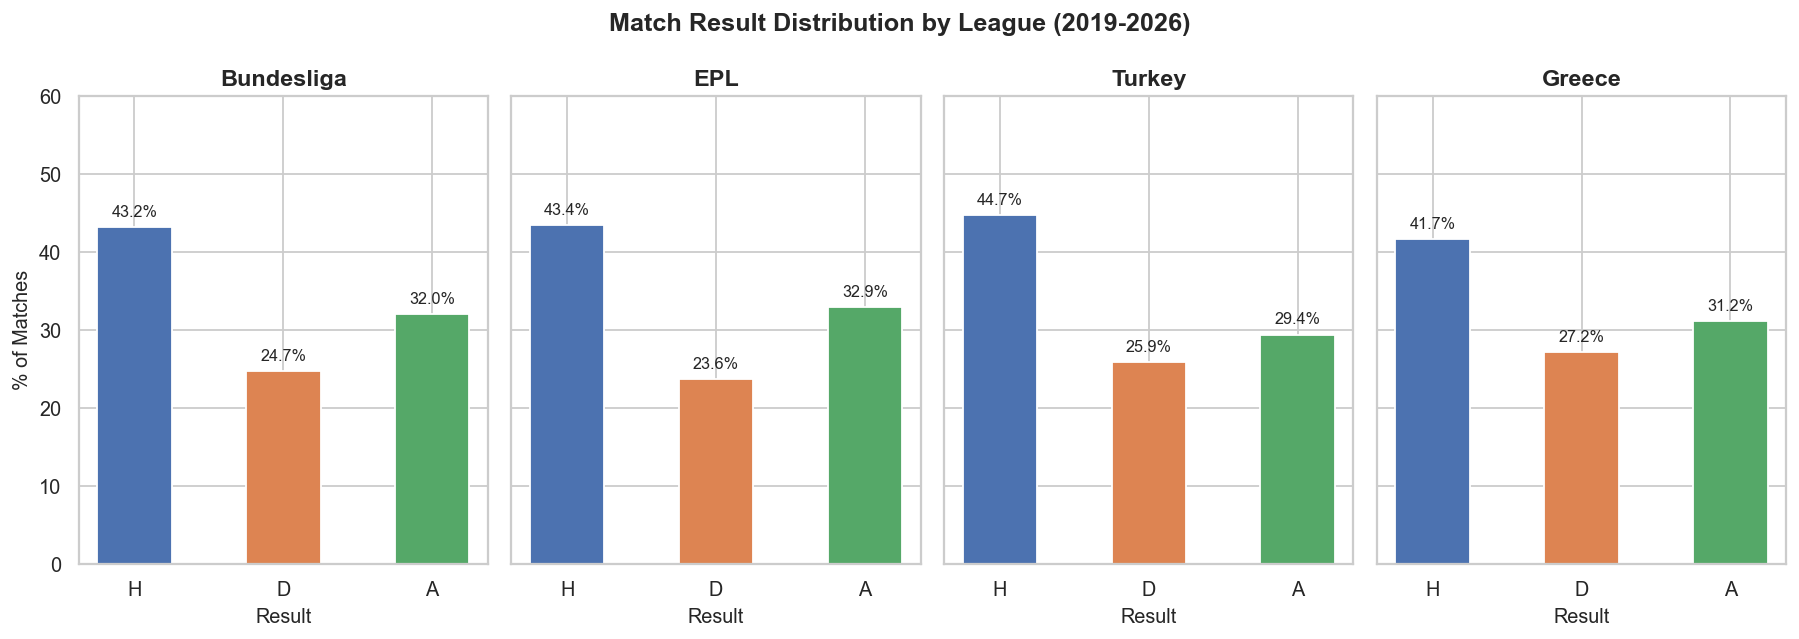

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

leagues = ['D1', 'E0', 'T1', 'G1']
league_names = {'D1': 'Bundesliga', 'E0': 'EPL', 'T1': 'Turkey', 'G1': 'Greece'}
colors = {'H': '#4C72B0', 'D': '#DD8452', 'A': '#55A868'}

for ax, league in zip(axes, leagues):
    data = master[master['league'] == league]['FTR'].value_counts(normalize=True) * 100
    data = data.reindex(['H', 'D', 'A'])
    bars = ax.bar(data.index, data.values, color=[colors[k] for k in data.index], width=0.5)
    ax.set_title(league_names[league], fontweight='bold')
    ax.set_xlabel('Result')
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('% of Matches')
fig.suptitle('Match Result Distribution by League (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_01_result_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** Result distributions are broadly consistent across all four leagues (H: 42–45%, D: 24–27%, A: 29–33%). This confirms that match outcome patterns alone are insufficient to detect integrity anomalies — validating the odds-based approach used in this project. Turkey shows the strongest home advantage bias (44.7% H, 29.4% A).

This serves as a baseline legitimacy check: if one league showed dramatically skewed results, that alone would be a red flag. Consistency tells us the manipulation signal, if present, hides in odds behaviour rather than scorelines.

### 4.2 Bookmaker spread by tier (opening odds — H1 primary visual)

Max − Avg odds spread per match, comparing elite vs mid-tier leagues. A wider spread indicates greater bookmaker disagreement — a key integrity signal.

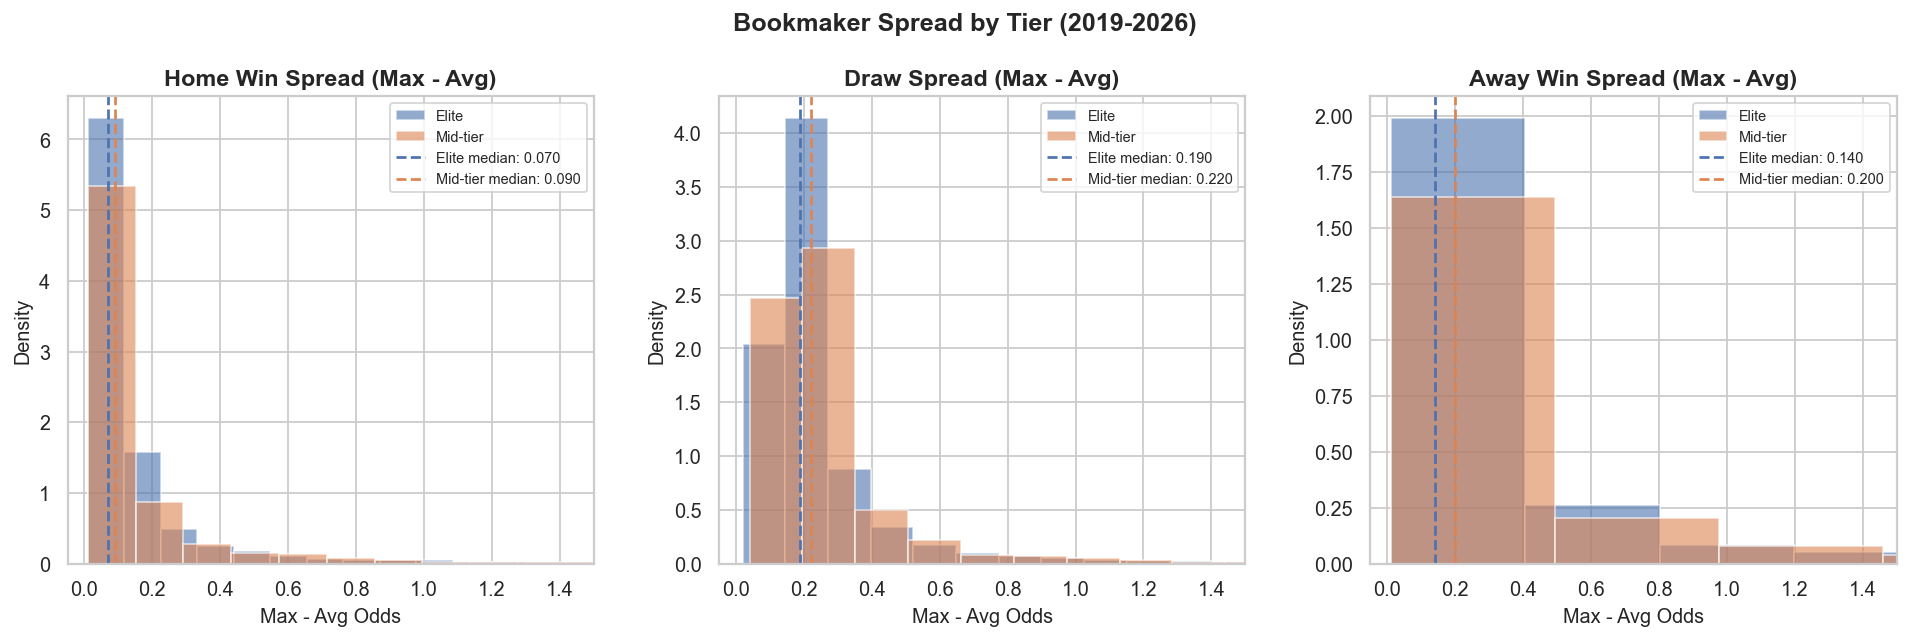

=== Bookmaker Spread Summary (median) ===

Home Win:
  Elite:    0.0700
  Mid-tier: 0.0900
  Mid-tier is +28.6% wider than elite

Draw:
  Elite:    0.1900
  Mid-tier: 0.2200
  Mid-tier is +15.8% wider than elite

Away Win:
  Elite:    0.1400
  Mid-tier: 0.2000
  Mid-tier is +42.9% wider than elite



In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    elite_data = master[master['tier'] == 'elite'][col].dropna()
    mid_data = master[master['tier'] == 'mid_tier'][col].dropna()

    ax.hist(elite_data, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
    ax.hist(mid_data, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
    ax.axvline(elite_data.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
               label=f'Elite median: {elite_data.median():.3f}')
    ax.axvline(mid_data.median(), color='#DD8452', linestyle='--', linewidth=1.5,
               label=f'Mid-tier median: {mid_data.median():.3f}')
    ax.set_title(f'{outcome_labels[outcome]} Spread (Max - Avg)', fontweight='bold')
    ax.set_xlabel('Max - Avg Odds')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.5)

fig.suptitle('Bookmaker Spread by Tier (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_02_bookmaker_spread_by_tier.png', bbox_inches='tight')
plt.show()

print("=== Bookmaker Spread Summary (median) ===\n")
for outcome in outcomes:
    col = f'bookmaker_spread_{outcome}'
    elite_med = master[master['tier'] == 'elite'][col].median()
    mid_med = master[master['tier'] == 'mid_tier'][col].median()
    diff_pct = ((mid_med - elite_med) / elite_med) * 100
    print(f"{outcome_labels[outcome]}:")
    print(f"  Elite:    {elite_med:.4f}")
    print(f"  Mid-tier: {mid_med:.4f}")
    print(f"  Mid-tier is {diff_pct:+.1f}% wider than elite\n")

**Observation (H1):** Mid-tier leagues show systematically wider bookmaker spreads than elite leagues across all three outcomes. The away win spread is 42.9% wider in mid-tier leagues — the largest gap observed. Elite distributions are tightly concentrated near zero; mid-tier distributions show significant right-skew with extreme outliers exceeding 1.0 odds units. This is the primary visual evidence for H1.

### 4.3 Bookmaker spread by league

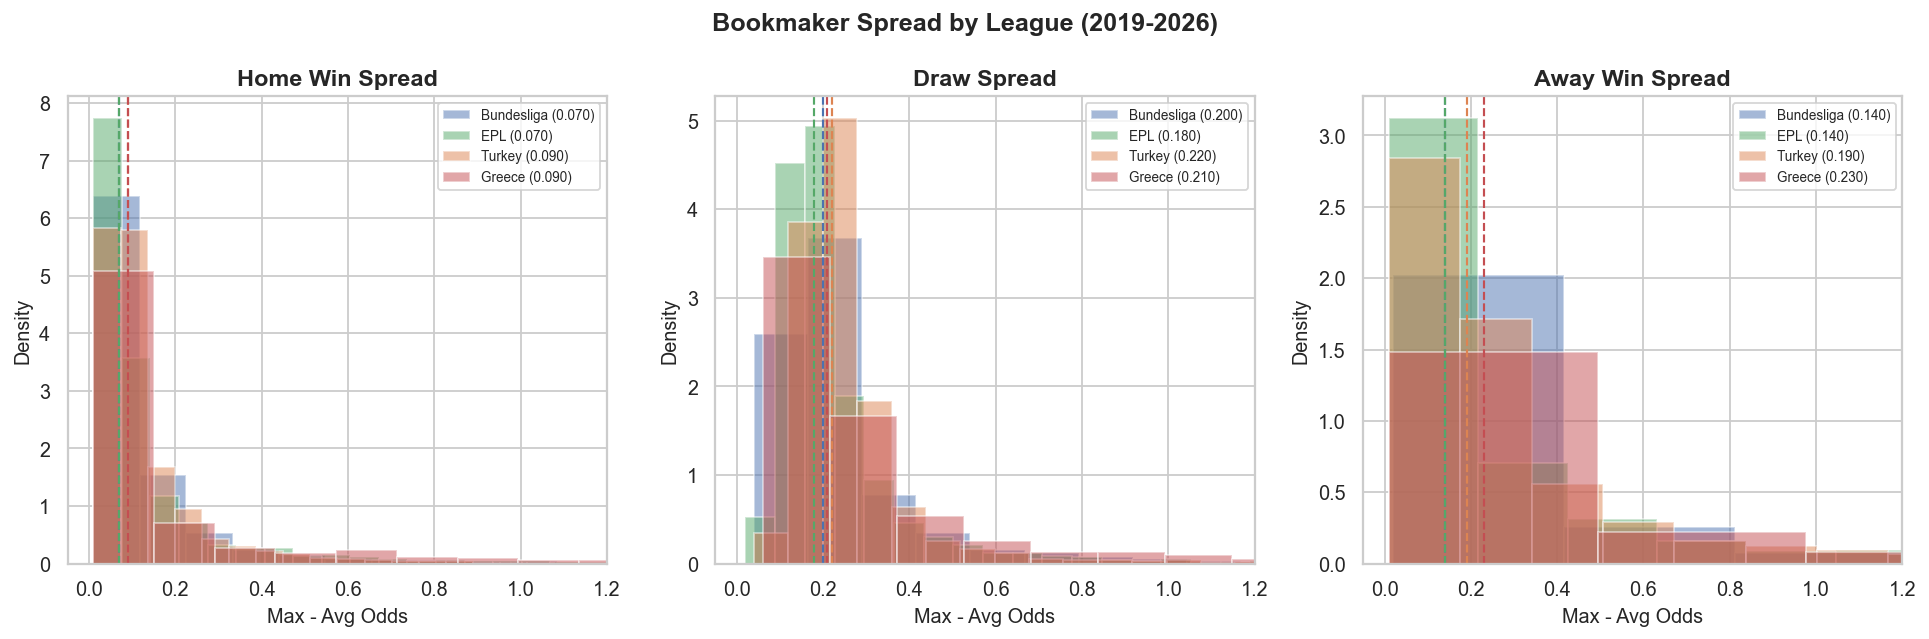

=== Median Spread by League ===

League           Home     Draw     Away     Mean
--------------------------------------------
Bundesliga     0.0700   0.2000   0.1400   0.1367
EPL            0.0700   0.1800   0.1400   0.1300
Turkey         0.0900   0.2200   0.1900   0.1667
Greece         0.0900   0.2100   0.2300   0.1767


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

league_colors = {'D1': '#4C72B0', 'E0': '#55A868', 'T1': '#DD8452', 'G1': '#C44E52'}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    for league in ['D1', 'E0', 'T1', 'G1']:
        data = master[master['league'] == league][col].dropna()
        ax.hist(data, bins=60, alpha=0.5, label=f"{league_names[league]} ({data.median():.3f})",
                color=league_colors[league], density=True)
        ax.axvline(data.median(), color=league_colors[league], linestyle='--', linewidth=1.2)
    ax.set_title(f'{outcome_labels[outcome]} Spread', fontweight='bold')
    ax.set_xlabel('Max - Avg Odds')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.05, 1.2)
    ax.legend(fontsize=7.5)

fig.suptitle('Bookmaker Spread by League (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_03_spread_by_league.png', bbox_inches='tight')
plt.show()

print("=== Median Spread by League ===\n")
print(f"{'League':<12} {'Home':>8} {'Draw':>8} {'Away':>8} {'Mean':>8}")
print("-" * 44)
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    h = master[master['league'] == league]['bookmaker_spread_H'].median()
    d = master[master['league'] == league]['bookmaker_spread_D'].median()
    a = master[master['league'] == league]['bookmaker_spread_A'].median()
    print(f"{name:<12} {h:>8.4f} {d:>8.4f} {a:>8.4f} {(h+d+a)/3:>8.4f}")

**Observation (League-level spread):** EPL is the most efficient market (mean spread 0.130), followed by Bundesliga (0.137), Turkey (0.167), and Greece (0.177). Greece's away win spread (0.230) is 64% wider than EPL — the largest single gap across all leagues and outcomes. This ranking is consistent with historical integrity records and suggests Greece warrants the closest scrutiny.

### 4.4 Bookmaker overround by league (closing odds)

The sum of implied probabilities (1/H + 1/D + 1/A) exceeds 1.0; the excess is the bookmaker's margin (overround). Higher overround = bookmaker charging more = less efficient market.

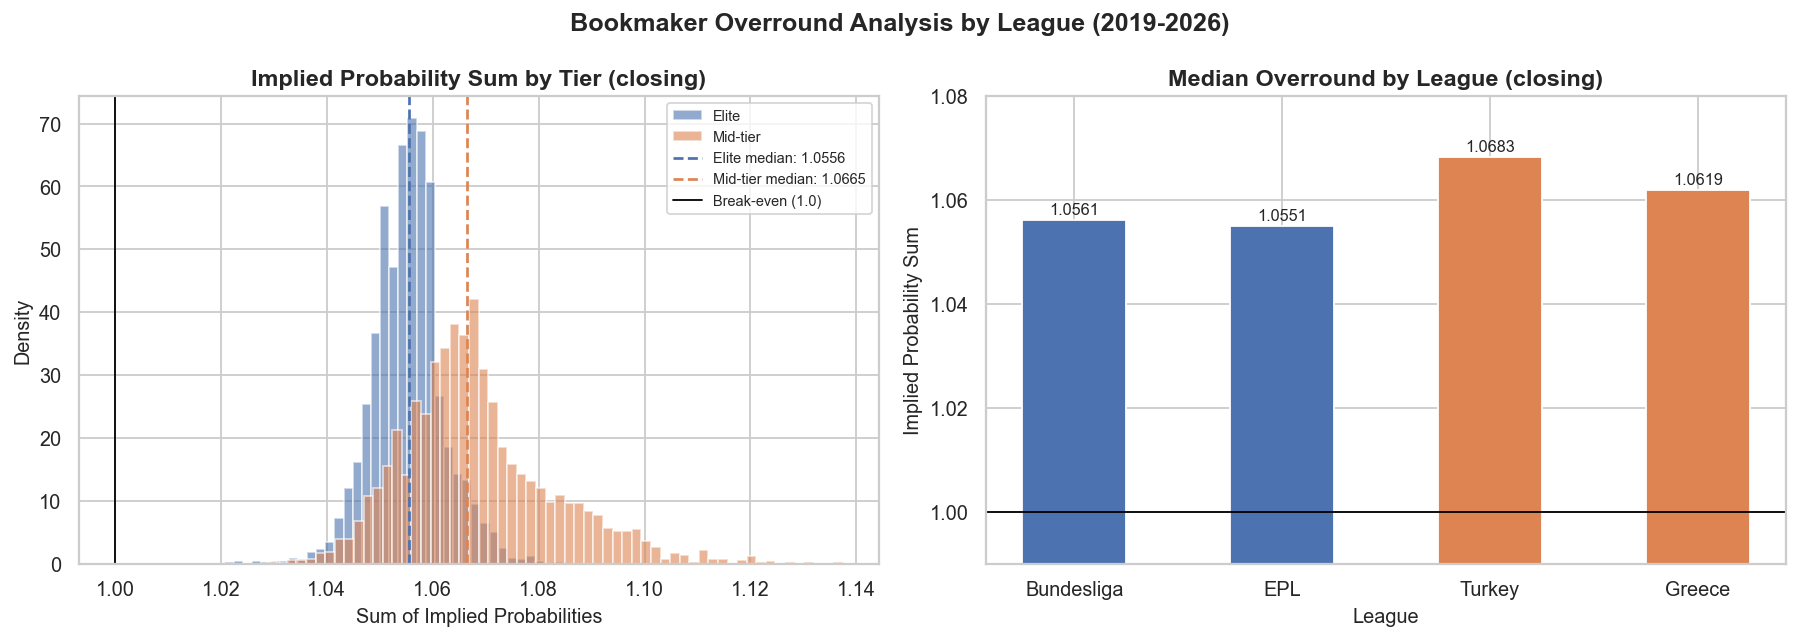

=== Overround Summary (closing odds) ===

Bundesliga: median=1.0561 -> bookmaker margin=5.61%
EPL: median=1.0551 -> bookmaker margin=5.51%
Turkey: median=1.0683 -> bookmaker margin=6.83%
Greece: median=1.0619 -> bookmaker margin=6.19%


In [21]:
ips_data = master.dropna(subset=['implied_prob_sum'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

elite_ips = ips_data[ips_data['tier'] == 'elite']['implied_prob_sum']
mid_ips = ips_data[ips_data['tier'] == 'mid_tier']['implied_prob_sum']

axes[0].hist(elite_ips, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
axes[0].hist(mid_ips, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
axes[0].axvline(elite_ips.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
                label=f'Elite median: {elite_ips.median():.4f}')
axes[0].axvline(mid_ips.median(), color='#DD8452', linestyle='--', linewidth=1.5,
                label=f'Mid-tier median: {mid_ips.median():.4f}')
axes[0].axvline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[0].set_title('Implied Probability Sum by Tier (closing)', fontweight='bold')
axes[0].set_xlabel('Sum of Implied Probabilities')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

overround_by_league = ips_data.groupby('league')['implied_prob_sum'].median().reindex(['D1', 'E0', 'T1', 'G1'])
bar_colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
bars = axes[1].bar(['Bundesliga', 'EPL', 'Turkey', 'Greece'], overround_by_league.values,
                   color=bar_colors, width=0.5)
axes[1].axhline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[1].set_title('Median Overround by League (closing)', fontweight='bold')
axes[1].set_xlabel('League')
axes[1].set_ylabel('Implied Probability Sum')
axes[1].set_ylim(0.99, 1.08)
for bar, val in zip(bars, overround_by_league.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Bookmaker Overround Analysis by League (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_04_implied_probability_sum.png', bbox_inches='tight')
plt.show()

print("=== Overround Summary (closing odds) ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    med = ips_data[ips_data['league'] == league]['implied_prob_sum'].median()
    margin_pct = (med - 1.0) * 100
    print(f"{name}: median={med:.4f} -> bookmaker margin={margin_pct:.2f}%")

**Observation (Overround):** Mid-tier leagues charge systematically higher bookmaker margins than elite leagues. Turkey and Greece both significantly exceed Bundesliga and EPL. The mid-tier distribution is wider and right-skewed, with extreme outliers that have no legitimate explanation in an efficient market — primary targets for the anomaly detector.

### 4.5 Seasonal spread trends

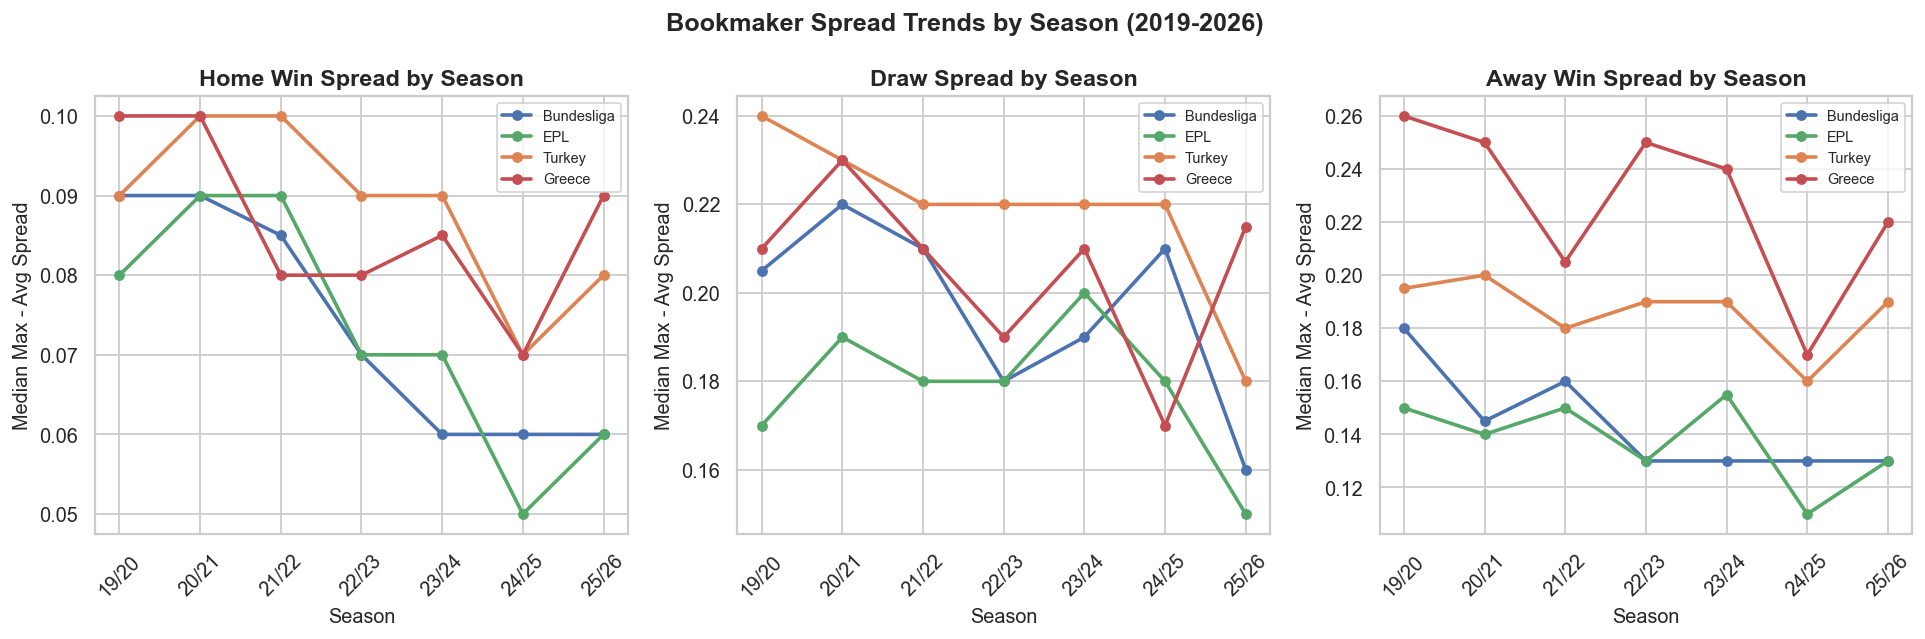

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
season_labels = ['19/20', '20/21', '21/22', '22/23', '23/24', '24/25', '25/26']

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    for league, name, color in zip(['D1', 'E0', 'T1', 'G1'],
                                    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
                                    ['#4C72B0', '#55A868', '#DD8452', '#C44E52']):
        season_medians = (master[master['league'] == league]
                          .groupby('season')[col].median()
                          .reindex(['1920','2021','2122','2223','2324','2425','2526']))
        ax.plot(season_labels, season_medians.values, marker='o',
                label=name, color=color, linewidth=2, markersize=5)
    ax.set_title(f'{outcome_labels[outcome]} Spread by Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Median Max - Avg Spread')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Bookmaker Spread Trends by Season (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_05_seasonal_trends.png', bbox_inches='tight')
plt.show()

**Observation (Seasonal Trends):** Elite leagues show consistent efficiency improvements over 7 seasons — EPL's away win spread fell from 0.150 to 0.110 by 24/25. Mid-tier leagues show no meaningful improvement — Turkey and Greece remain structurally elevated. Greece's resistance to efficiency improvement is the most notable pattern. The 19/20 Greece spike coincides with the COVID-interrupted season and warrants contextual flagging.

## 5. Season Phase Analysis (H4)

Testing H4: bookmaker disagreement concentrates toward the end of the season. Matches are grouped into quintiles by their position within the league-season.

### 5.1 End-of-season spread concentration

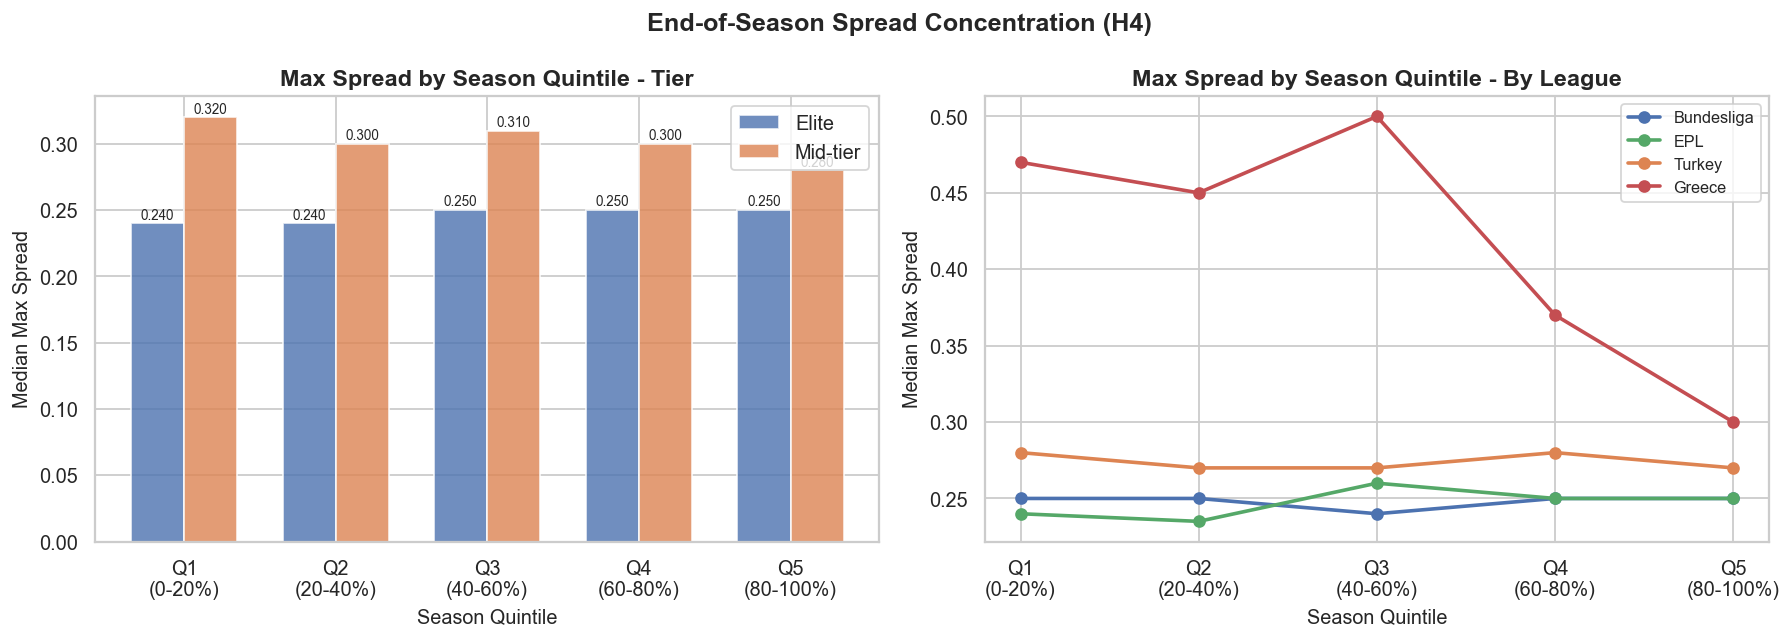

=== Q5 vs Q1 change (end vs start of season) ===

Bundesliga  : Q1=0.2500 -> Q5=0.2500  (+0.0%)
EPL         : Q1=0.2400 -> Q5=0.2500  (+4.2%)
Turkey      : Q1=0.2800 -> Q5=0.2700  (-3.6%)
Greece      : Q1=0.4700 -> Q5=0.3000  (-36.2%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quintile_labels = ['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']

# Chart 1 - by tier
quintile_tier = master.groupby(['season_quintile', 'tier'], observed=True)['max_spread'].median().unstack()
x = range(5)
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x], quintile_tier['elite'], width, label='Elite', color='#4C72B0', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x], quintile_tier['mid_tier'], width, label='Mid-tier', color='#DD8452', alpha=0.8)
for bars in (bars1, bars2):
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
axes[0].set_title('Max Spread by Season Quintile - Tier', fontweight='bold')
axes[0].set_xlabel('Season Quintile')
axes[0].set_ylabel('Median Max Spread')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(quintile_labels)
axes[0].legend()

# Chart 2 - by league
quintile_league = master.groupby(['season_quintile', 'league'], observed=True)['max_spread'].median().unstack()
for league, name, color in zip(['D1', 'E0', 'T1', 'G1'],
                                ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
                                ['#4C72B0', '#55A868', '#DD8452', '#C44E52']):
    axes[1].plot(quintile_labels, quintile_league[league].values, marker='o',
                 label=name, color=color, linewidth=2, markersize=6)
axes[1].set_title('Max Spread by Season Quintile - By League', fontweight='bold')
axes[1].set_xlabel('Season Quintile')
axes[1].set_ylabel('Median Max Spread')
axes[1].legend(fontsize=9)

fig.suptitle('End-of-Season Spread Concentration (H4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_06_end_of_season_concentration.png', bbox_inches='tight')
plt.show()

print("=== Q5 vs Q1 change (end vs start of season) ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    q1 = quintile_league.loc['Q1\n(0-20%)', league]
    q5 = quintile_league.loc['Q5\n(80-100%)', league]
    change = ((q5 - q1) / q1) * 100
    print(f"{name:<12}: Q1={q1:.4f} -> Q5={q5:.4f}  ({change:+.1f}%)")

**Observation (H4):** Contrary to expectations, end-of-season spread concentration is not observed. Greece shows the opposite pattern — spreads peak in Q3 (mid-season) and decline toward Q5 (−35.5% from Q1). Elite leagues show no meaningful seasonal variation. The Greek Super League's split-round format (top 6 vs bottom 10 in the final phase) is a likely structural explanation. **H4 is not supported in its original form** — season position alone is insufficient as an integrity signal and will be treated as a contextual feature, not a directional predictor.

## 6. Bookmaker Accuracy & Calibration

Analysis of how well bookmaker prices predict actual outcomes — favourite accuracy, calibration, favourite-longshot bias, and draw mispricing.

### 6.1 Favourite win rate by league and tier

For each match, identify the bookmaker's favourite (lowest odds = highest implied probability) and compare against the actual result. Uses opening B365 odds, consistent with favourite win rate literature.

In [24]:
def get_favourite(row):
    probs = {'H': 1/row['B365H'], 'D': 1/row['B365D'], 'A': 1/row['B365A']}
    return max(probs, key=probs.get)

accuracy_df = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
accuracy_df['favourite'] = accuracy_df.apply(get_favourite, axis=1)
accuracy_df['favourite_won'] = accuracy_df['favourite'] == accuracy_df['FTR']

print("=== Favourite type distribution ===")
print(accuracy_df['favourite'].value_counts())
print(f"\nOverall favourite win rate: {accuracy_df['favourite_won'].mean()*100:.1f}%")

=== Favourite type distribution ===
favourite
H    5944
A    2940
D       4
Name: count, dtype: int64

Overall favourite win rate: 53.1%


#### Special case: draw as favourite

Only 4 matches had a draw as the implied favourite — all in Greece and Turkey, mostly at end of season. These represent extreme cases where bookmakers could not separate two evenly-matched teams or anticipated low motivation (e.g. a title-secured side).

In [25]:
draw_favs = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
draw_favs['favourite'] = draw_favs.apply(get_favourite, axis=1)
draw_favs = draw_favs[draw_favs['favourite'] == 'D']

cols = ['Date', 'HomeTeam', 'AwayTeam', 'league', 'season', 'B365H', 'B365D', 'B365A', 'FTR']
print(draw_favs[cols].to_string(index=False))

      Date         HomeTeam         AwayTeam league season  B365H  B365D  B365A FTR
2023-05-06         Giannina Asteras Tripolis     G1   2223    2.6   2.25   4.00   H
2024-04-27 Asteras Tripolis        OFI Crete     G1   2324    2.8   2.63   3.20   D
2024-05-18      Kayserispor        Konyaspor     T1   2324    3.0   2.40   3.10   D
2024-05-26        Konyaspor      Galatasaray     T1   2324    9.0   1.95   2.05   A


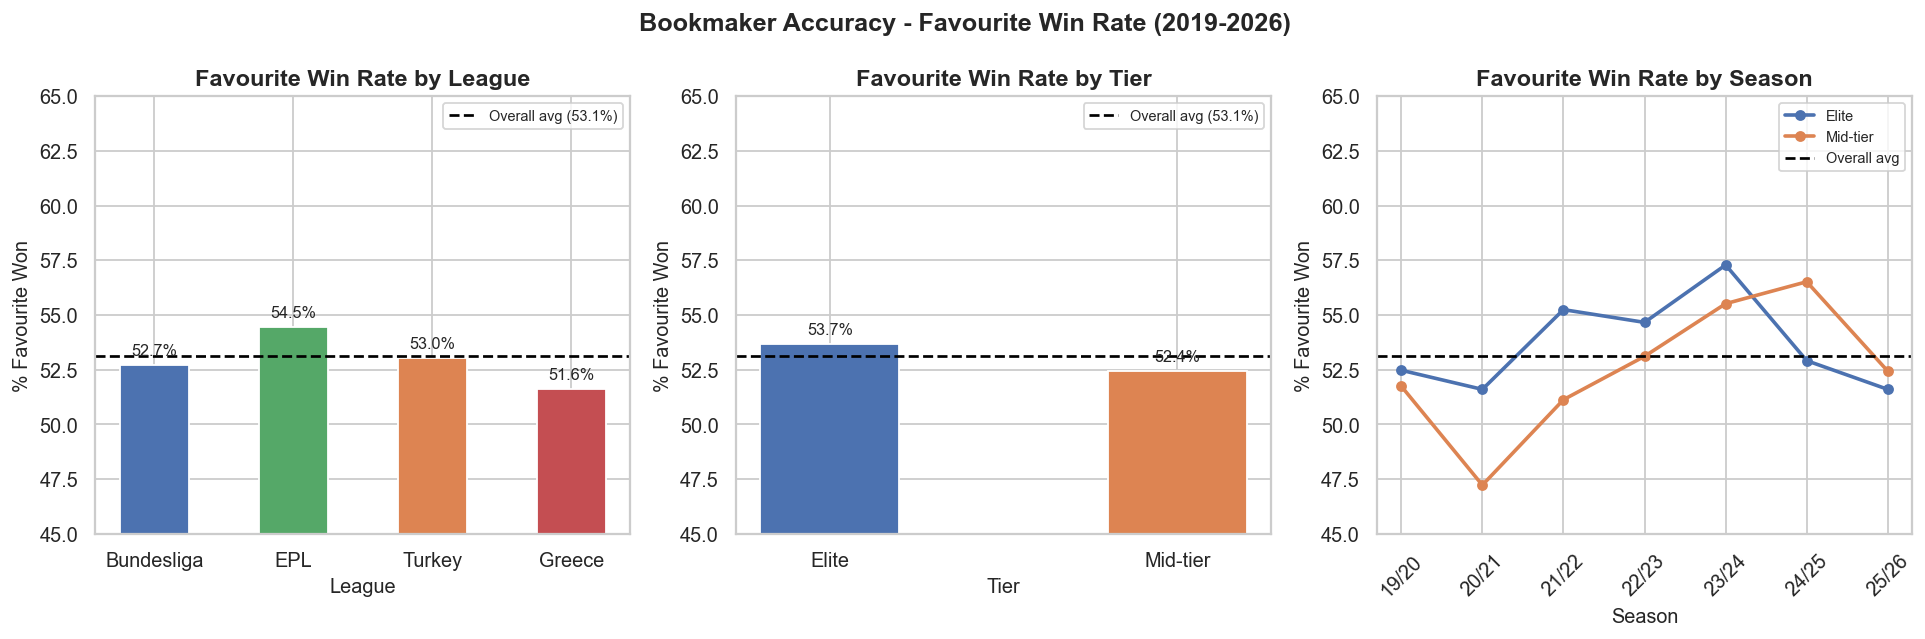

=== Favourite Win Rate by League ===

Bundesliga  : 52.7% (2142 matches)
EPL         : 54.5% (2660 matches)
Turkey      : 53.0% (2435 matches)
Greece      : 51.6% (1647 matches)

=== By favourite type ===

Bundesliga   favourite=H: 53.6% (1393 matches)
EPL          favourite=H: 55.6% (1673 matches)
Turkey       favourite=H: 53.6% (1725 matches)
Greece       favourite=H: 50.5% (1153 matches)

Bundesliga   favourite=A: 51.1% (749 matches)
EPL          favourite=A: 52.5% (987 matches)
Turkey       favourite=A: 51.5% (710 matches)
Greece       favourite=A: 54.3% (494 matches)



In [26]:
# Remove the 4 draw-favourite matches for the win-rate analysis
accuracy_df = accuracy_df[accuracy_df['favourite'] != 'D']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 - by league
win_rate_league = accuracy_df.groupby('league')['favourite_won'].mean() * 100
win_rate_league = win_rate_league.reindex(['D1', 'E0', 'T1', 'G1'])
overall = accuracy_df['favourite_won'].mean() * 100
bars = axes[0].bar(['Bundesliga', 'EPL', 'Turkey', 'Greece'], win_rate_league.values,
                   color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], width=0.5)
axes[0].axhline(overall, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall:.1f}%)')
axes[0].set_ylim(45, 65)
axes[0].set_title('Favourite Win Rate by League', fontweight='bold')
axes[0].set_xlabel('League'); axes[0].set_ylabel('% Favourite Won')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, win_rate_league.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 2 - by tier
win_rate_tier = accuracy_df.groupby('tier')['favourite_won'].mean() * 100
bars2 = axes[1].bar(['Elite', 'Mid-tier'], [win_rate_tier['elite'], win_rate_tier['mid_tier']],
                    color=['#4C72B0', '#DD8452'], width=0.4)
axes[1].axhline(overall, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall:.1f}%)')
axes[1].set_ylim(45, 65)
axes[1].set_title('Favourite Win Rate by Tier', fontweight='bold')
axes[1].set_xlabel('Tier'); axes[1].set_ylabel('% Favourite Won')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, [win_rate_tier['elite'], win_rate_tier['mid_tier']]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 3 - by season and tier
win_rate_season = accuracy_df.groupby(['season', 'tier'])['favourite_won'].mean() * 100
for tier, color, label in zip(['elite', 'mid_tier'], ['#4C72B0', '#DD8452'], ['Elite', 'Mid-tier']):
    vals = win_rate_season.xs(tier, level='tier').reindex(['1920','2021','2122','2223','2324','2425','2526'])
    axes[2].plot(season_labels, vals.values, marker='o', color=color, label=label, linewidth=2, markersize=5)
axes[2].axhline(overall, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
axes[2].set_title('Favourite Win Rate by Season', fontweight='bold')
axes[2].set_xlabel('Season'); axes[2].set_ylabel('% Favourite Won')
axes[2].legend(fontsize=8); axes[2].tick_params(axis='x', rotation=45); axes[2].set_ylim(45, 65)

fig.suptitle('Bookmaker Accuracy - Favourite Win Rate (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_07_favourite_win_rate.png', bbox_inches='tight')
plt.show()

print("=== Favourite Win Rate by League ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    rate = accuracy_df[accuracy_df['league'] == league]['favourite_won'].mean() * 100
    total = len(accuracy_df[accuracy_df['league'] == league])
    print(f"{name:<12}: {rate:.1f}% ({total} matches)")

print(f"\n=== By favourite type ===\n")
for fav in ['H', 'A']:
    for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
        subset = accuracy_df[(accuracy_df['league'] == league) & (accuracy_df['favourite'] == fav)]
        if len(subset) > 0:
            print(f"{name:<12} favourite={fav}: {subset['favourite_won'].mean()*100:.1f}% ({len(subset)} matches)")
    print()

**Observation (Bookmaker Accuracy):** EPL is the most accurately priced league (54.5% favourite win rate); Greece the least (51.7%). Greece's inverted home/away accuracy — home favourites win only 50.5% (near random) while away favourites win 54.4%, the opposite of all other leagues — likely reflects a genuinely weak home advantage (dominant Athens/Thessaloniki clubs travel well) but is worth flagging. The COVID-affected 20/21 season shows a severe accuracy drop in mid-tier leagues (47.5%), confirming behind-closed-doors matches as a confound.

### 6.2 Market calibration curve (closing odds, normalised)

When the market says an outcome has probability X, does it occur X% of the time? Calibration compares normalised implied probability against realised frequency.

#### Methodology note: implied probability normalisation

Raw implied probabilities (1/odds) include the bookmaker's margin and sum to >1.0. To compare predicted vs realised, we strip the margin by **multiplicative normalisation** — dividing each outcome's implied probability by the row total so the three sum to 1.0.

**Assumption:** this spreads the margin proportionally across outcomes. Real bookmakers load disproportionate margin onto longshots, so proportional normalisation may leave a small residual inflation on high-odds outcomes — meaning part of any measured favourite-longshot bias could be partly attributable to the method. **Alternatives:** additive normalisation and Shin's method (the academic standard); multiplicative is used here for transparency, with Shin's noted for future robustness checks.

In [27]:
# Build long-format frame: each match -> 3 rows (H, D, A) with normalised closing implied prob
eff = master.dropna(subset=['B365CH', 'B365CD', 'B365CA']).copy()

rows = []
for _, r in eff.iterrows():
    raw = {'H': 1/r['B365CH'], 'D': 1/r['B365CD'], 'A': 1/r['B365CA']}
    total = sum(raw.values())
    for outcome in ['H', 'D', 'A']:
        rows.append({
            'league': r['league'], 'tier': r['tier'], 'season': r['season'],
            'outcome': outcome,
            'implied_norm': raw[outcome] / total,
            'occurred': int(r['FTR'] == outcome)
        })

long_df = pd.DataFrame(rows)
print(f"Long-format rows: {len(long_df):,}")
print(f"\nMean normalised implied prob by outcome:")
print(long_df.groupby('outcome')['implied_norm'].mean().round(4))
print(f"\nActual occurrence rate by outcome:")
print(long_df.groupby('outcome')['occurred'].mean().round(4))

Long-format rows: 26,745

Mean normalised implied prob by outcome:
outcome
A    0.3155
D    0.2439
H    0.4407
Name: implied_norm, dtype: float64

Actual occurrence rate by outcome:
outcome
A    0.3141
D    0.2518
H    0.4341
Name: occurred, dtype: float64


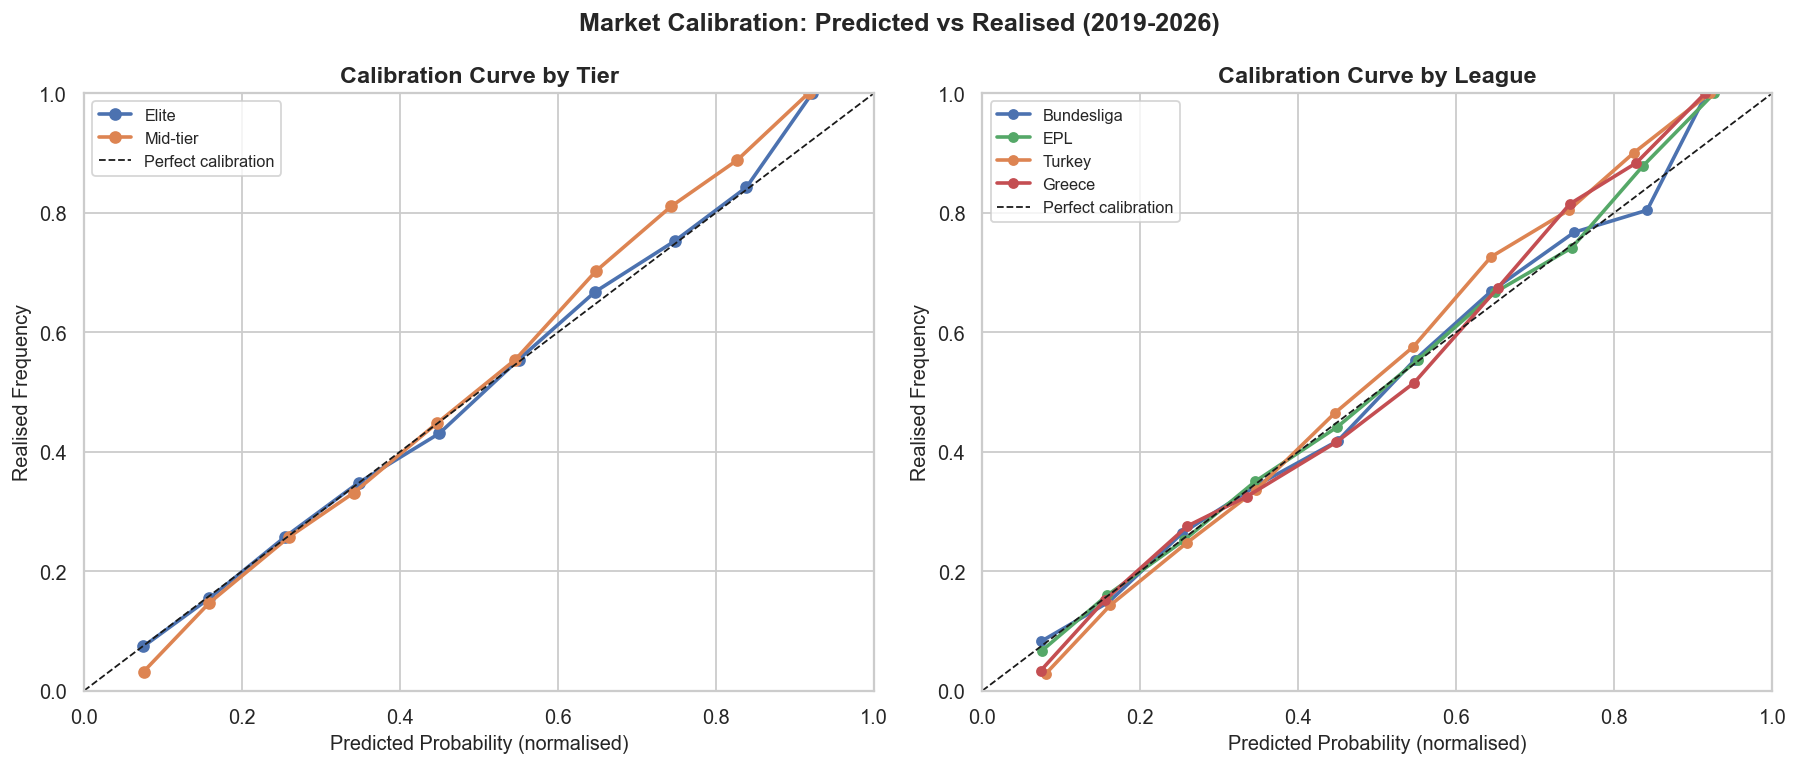

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]

for tier, color, label in zip(['elite', 'mid_tier'], ['#4C72B0', '#DD8452'], ['Elite', 'Mid-tier']):
    sub = long_df[long_df['tier'] == tier].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'), realised=('occurred', 'mean')).dropna()
    axes[0].plot(grouped['predicted'], grouped['realised'], marker='o', color=color, label=label, linewidth=2, markersize=6)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_title('Calibration Curve by Tier', fontweight='bold')
axes[0].set_xlabel('Predicted Probability (normalised)'); axes[0].set_ylabel('Realised Frequency')
axes[0].legend(fontsize=9); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

for league, name, color in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    sub = long_df[long_df['league'] == league].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'), realised=('occurred', 'mean')).dropna()
    axes[1].plot(grouped['predicted'], grouped['realised'], marker='o', color=color, label=name, linewidth=2, markersize=5)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[1].set_title('Calibration Curve by League', fontweight='bold')
axes[1].set_xlabel('Predicted Probability (normalised)'); axes[1].set_ylabel('Realised Frequency')
axes[1].legend(fontsize=9); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

fig.suptitle('Market Calibration: Predicted vs Realised (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_calibration_curve.png', bbox_inches='tight')
plt.show()

**Observation (Calibration):** Both tiers and all four leagues hug the diagonal closely — the market is well-calibrated overall. Mid-tier shows mild longshot underperformance at the bottom-left and slight favourite outperformance at the top-right, consistent with favourite-longshot bias. Individual league wiggles should be read cautiously given small per-bucket sample sizes.

### 6.3 Favourite-longshot bias (closing odds)

Buckets matches by implied probability and plots the gap between realised and predicted. Favourite-longshot bias: longshots win less often than implied, favourites win more often.

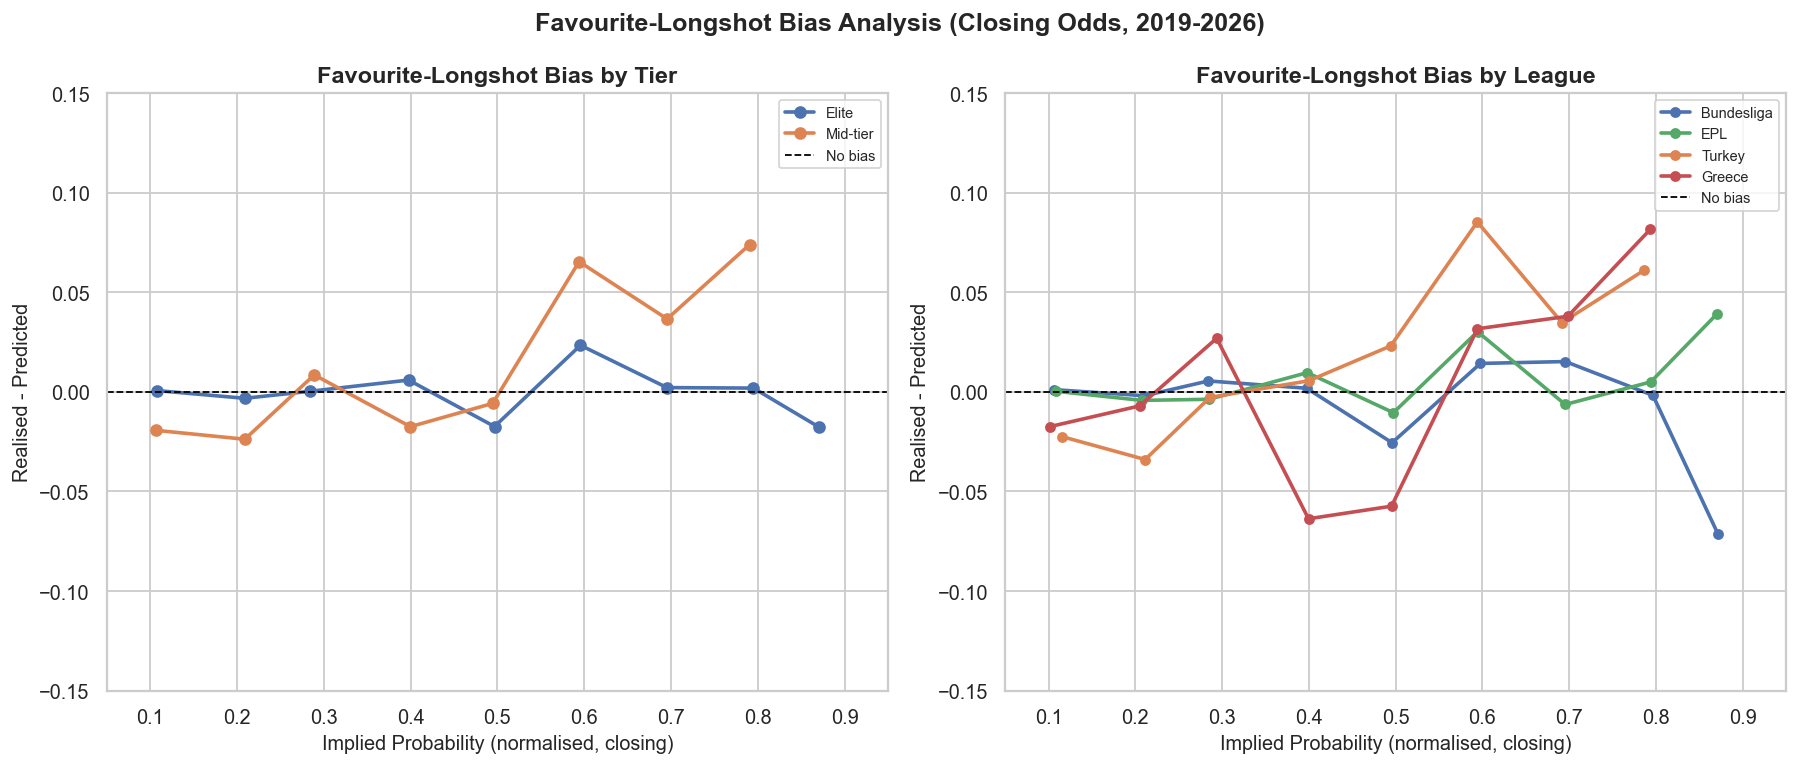

In [29]:
# Reuse the long_df built in Section 6.2 (closing odds, normalised)
flb_long = long_df.copy()

bucket_edges = [0, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 1.0]
bucket_centers = [(bucket_edges[i] + bucket_edges[i+1])/2 for i in range(len(bucket_edges)-1)]
flb_long['bucket'] = pd.cut(flb_long['implied_norm'], bins=bucket_edges, labels=bucket_centers)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    sub = flb_long[flb_long['tier'] == tier]
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'), realised=('occurred', 'mean'), n=('occurred', 'size')).dropna()
    grouped = grouped[grouped['n'] >= 30]
    axes[0].plot(grouped['predicted'], grouped['realised'] - grouped['predicted'],
                 marker='o', color=color, label=label, linewidth=2, markersize=6)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, label='No bias')
axes[0].set_title('Favourite-Longshot Bias by Tier', fontweight='bold')
axes[0].set_xlabel('Implied Probability (normalised, closing)'); axes[0].set_ylabel('Realised - Predicted')
axes[0].legend(fontsize=8); axes[0].set_xlim(0.05, 0.95); axes[0].set_ylim(-0.15, 0.15)

for league, name, color in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    sub = flb_long[flb_long['league'] == league]
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'), realised=('occurred', 'mean'), n=('occurred', 'size')).dropna()
    grouped = grouped[grouped['n'] >= 20]
    axes[1].plot(grouped['predicted'], grouped['realised'] - grouped['predicted'],
                 marker='o', color=color, label=name, linewidth=2, markersize=5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, label='No bias')
axes[1].set_title('Favourite-Longshot Bias by League', fontweight='bold')
axes[1].set_xlabel('Implied Probability (normalised, closing)'); axes[1].set_ylabel('Realised - Predicted')
axes[1].legend(fontsize=8); axes[1].set_xlim(0.05, 0.95); axes[1].set_ylim(-0.15, 0.15)

fig.suptitle('Favourite-Longshot Bias Analysis (Closing Odds, 2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_09_favourite_longshot_bias.png', bbox_inches='tight')
plt.show()

**Observation (Favourite-Longshot Bias):** Elite leagues show near-perfect calibration; EPL is flattest. Mid-tier leagues show systematic FLB: longshots (0.1–0.2) win less than predicted, while strong favourites (0.6–0.8) win more. Greece shows additional miscalibration in the 0.4–0.5 band — the range where manipulation is most profitable and hardest to detect. (Note the normalisation caveat: part of the longshot effect may be method-related.)

### 6.4 Draw mispricing analysis (closing odds)

Are draws systematically mis-priced per league? The draw is the classic match-fixing vehicle (both clubs can benefit from an arranged draw), so persistent draw underpricing is integrity-relevant.

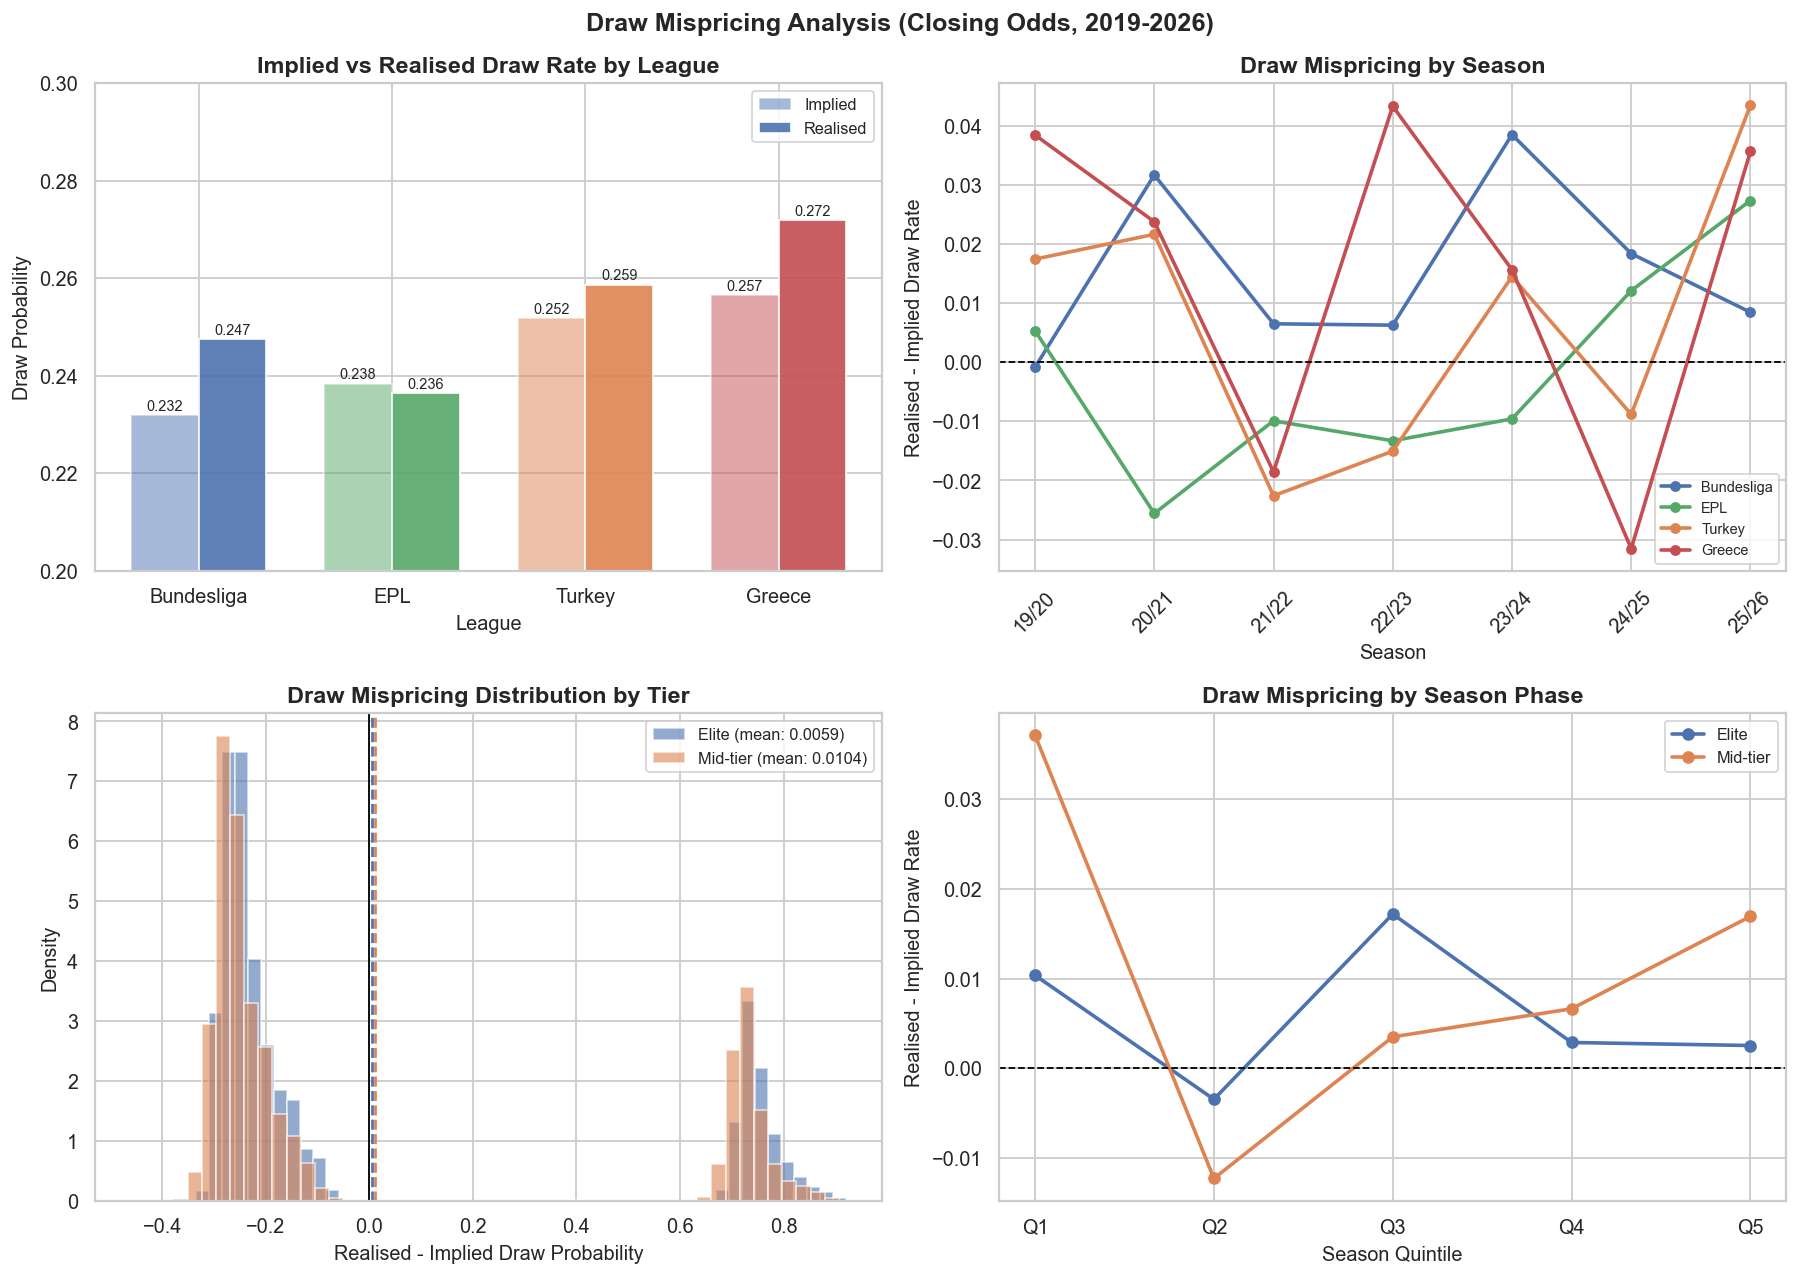

=== Draw Mispricing Summary ===

League          Implied   Realised       Bias     Bias %
----------------------------------------------------
Bundesliga       0.2318     0.2474    +0.0156      +6.7%
EPL              0.2384     0.2365    -0.0019      -0.8%
Turkey           0.2517     0.2587    +0.0069      +2.8%
Greece           0.2565     0.2719    +0.0154      +6.0%


In [30]:
draw_df = master.dropna(subset=['B365CH', 'B365CD', 'B365CA']).copy()
draw_df['raw_draw_prob'] = 1 / draw_df['B365CD']
draw_df['implied_sum'] = (1/draw_df['B365CH'] + 1/draw_df['B365CD'] + 1/draw_df['B365CA'])
draw_df['draw_prob_norm'] = draw_df['raw_draw_prob'] / draw_df['implied_sum']
draw_df['draw_occurred'] = (draw_df['FTR'] == 'D').astype(int)
draw_df['draw_mispricing'] = draw_df['draw_occurred'] - draw_df['draw_prob_norm']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - implied vs realised by league
league_stats = []
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    sub = draw_df[draw_df['league'] == league]
    league_stats.append({'league': name, 'implied': sub['draw_prob_norm'].mean(),
                         'realised': sub['draw_occurred'].mean(), 'bias': sub['draw_mispricing'].mean()})
stats_df = pd.DataFrame(league_stats)
x = range(len(stats_df)); width = 0.35
lc = ['#4C72B0','#55A868','#DD8452','#C44E52']
axes[0,0].bar([i - width/2 for i in x], stats_df['implied'], width, label='Implied', color=lc, alpha=0.5)
axes[0,0].bar([i + width/2 for i in x], stats_df['realised'], width, label='Realised', color=lc, alpha=0.9)
axes[0,0].set_title('Implied vs Realised Draw Rate by League', fontweight='bold')
axes[0,0].set_xlabel('League'); axes[0,0].set_ylabel('Draw Probability')
axes[0,0].set_xticks(list(x)); axes[0,0].set_xticklabels(stats_df['league'])
axes[0,0].legend(fontsize=9); axes[0,0].set_ylim(0.20, 0.30)
for i, row in stats_df.iterrows():
    axes[0,0].text(i - width/2, row['implied']+0.001, f"{row['implied']:.3f}", ha='center', fontsize=8)
    axes[0,0].text(i + width/2, row['realised']+0.001, f"{row['realised']:.3f}", ha='center', fontsize=8)

# Chart 2 - by season
for league, name, color in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    season_bias = (draw_df[draw_df['league'] == league].groupby('season')['draw_mispricing'].mean()
                   .reindex(['1920','2021','2122','2223','2324','2425','2526']))
    axes[0,1].plot(season_labels, season_bias.values, marker='o', color=color, label=name, linewidth=2, markersize=5)
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0,1].set_title('Draw Mispricing by Season', fontweight='bold')
axes[0,1].set_xlabel('Season'); axes[0,1].set_ylabel('Realised - Implied Draw Rate')
axes[0,1].legend(fontsize=8); axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - distribution by tier
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    data = draw_df[draw_df['tier'] == tier]['draw_mispricing']
    axes[1,0].hist(data, bins=50, alpha=0.6, density=True, color=color, label=f'{label} (mean: {data.mean():.4f})')
    axes[1,0].axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1,0].set_title('Draw Mispricing Distribution by Tier', fontweight='bold')
axes[1,0].set_xlabel('Realised - Implied Draw Probability'); axes[1,0].set_ylabel('Density')
axes[1,0].legend(fontsize=9)

# Chart 4 - by season quintile
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    sub = draw_df[draw_df['tier'] == tier]
    q_bias = sub.groupby('season_quintile', observed=True)['draw_mispricing'].mean()
    axes[1,1].plot([str(q)[:2] for q in q_bias.index], q_bias.values, marker='o', color=color, label=label, linewidth=2, markersize=6)
axes[1,1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1,1].set_title('Draw Mispricing by Season Phase', fontweight='bold')
axes[1,1].set_xlabel('Season Quintile'); axes[1,1].set_ylabel('Realised - Implied Draw Rate')
axes[1,1].legend(fontsize=9)

fig.suptitle('Draw Mispricing Analysis (Closing Odds, 2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_10_draw_mispricing.png', bbox_inches='tight')
plt.show()

print("=== Draw Mispricing Summary ===\n")
print(f"{'League':<12} {'Implied':>10} {'Realised':>10} {'Bias':>10} {'Bias %':>10}")
print("-" * 52)
for _, row in stats_df.iterrows():
    print(f"{row['league']:<12} {row['implied']:>10.4f} {row['realised']:>10.4f} "
          f"{row['bias']:>+10.4f} {(row['bias']/row['implied'])*100:>+9.1f}%")

**Observation (Draw Mispricing):** EPL is the only correctly priced draw market (bias −0.8%). All others underprice draws: Bundesliga (+6.7%), Greece (+6.1%), Turkey (+2.8%). Greece draws occur 27.2% vs 25.7% predicted. Extreme seasonal spikes — Greece 22/23 (+4.3pp) and Turkey 25/26 (+4.4pp) — are flagged for the anomaly detection phase. Mid-tier draw mispricing concentrates in Q1 and dissipates toward season end, pointing to early-season uncertainty rather than end-of-season manipulation. The Bundesliga's recent draw underpricing is a structural market characteristic.

## 7. Drift Analysis — Opening to Closing Movement

How much do odds move from open to close, and does the pattern differ by league? Large drift = significant information arrived pre-kickoff. Pinnacle drift specifically reflects sharp/informed money.

### 7.1 B365 and Pinnacle drift by tier

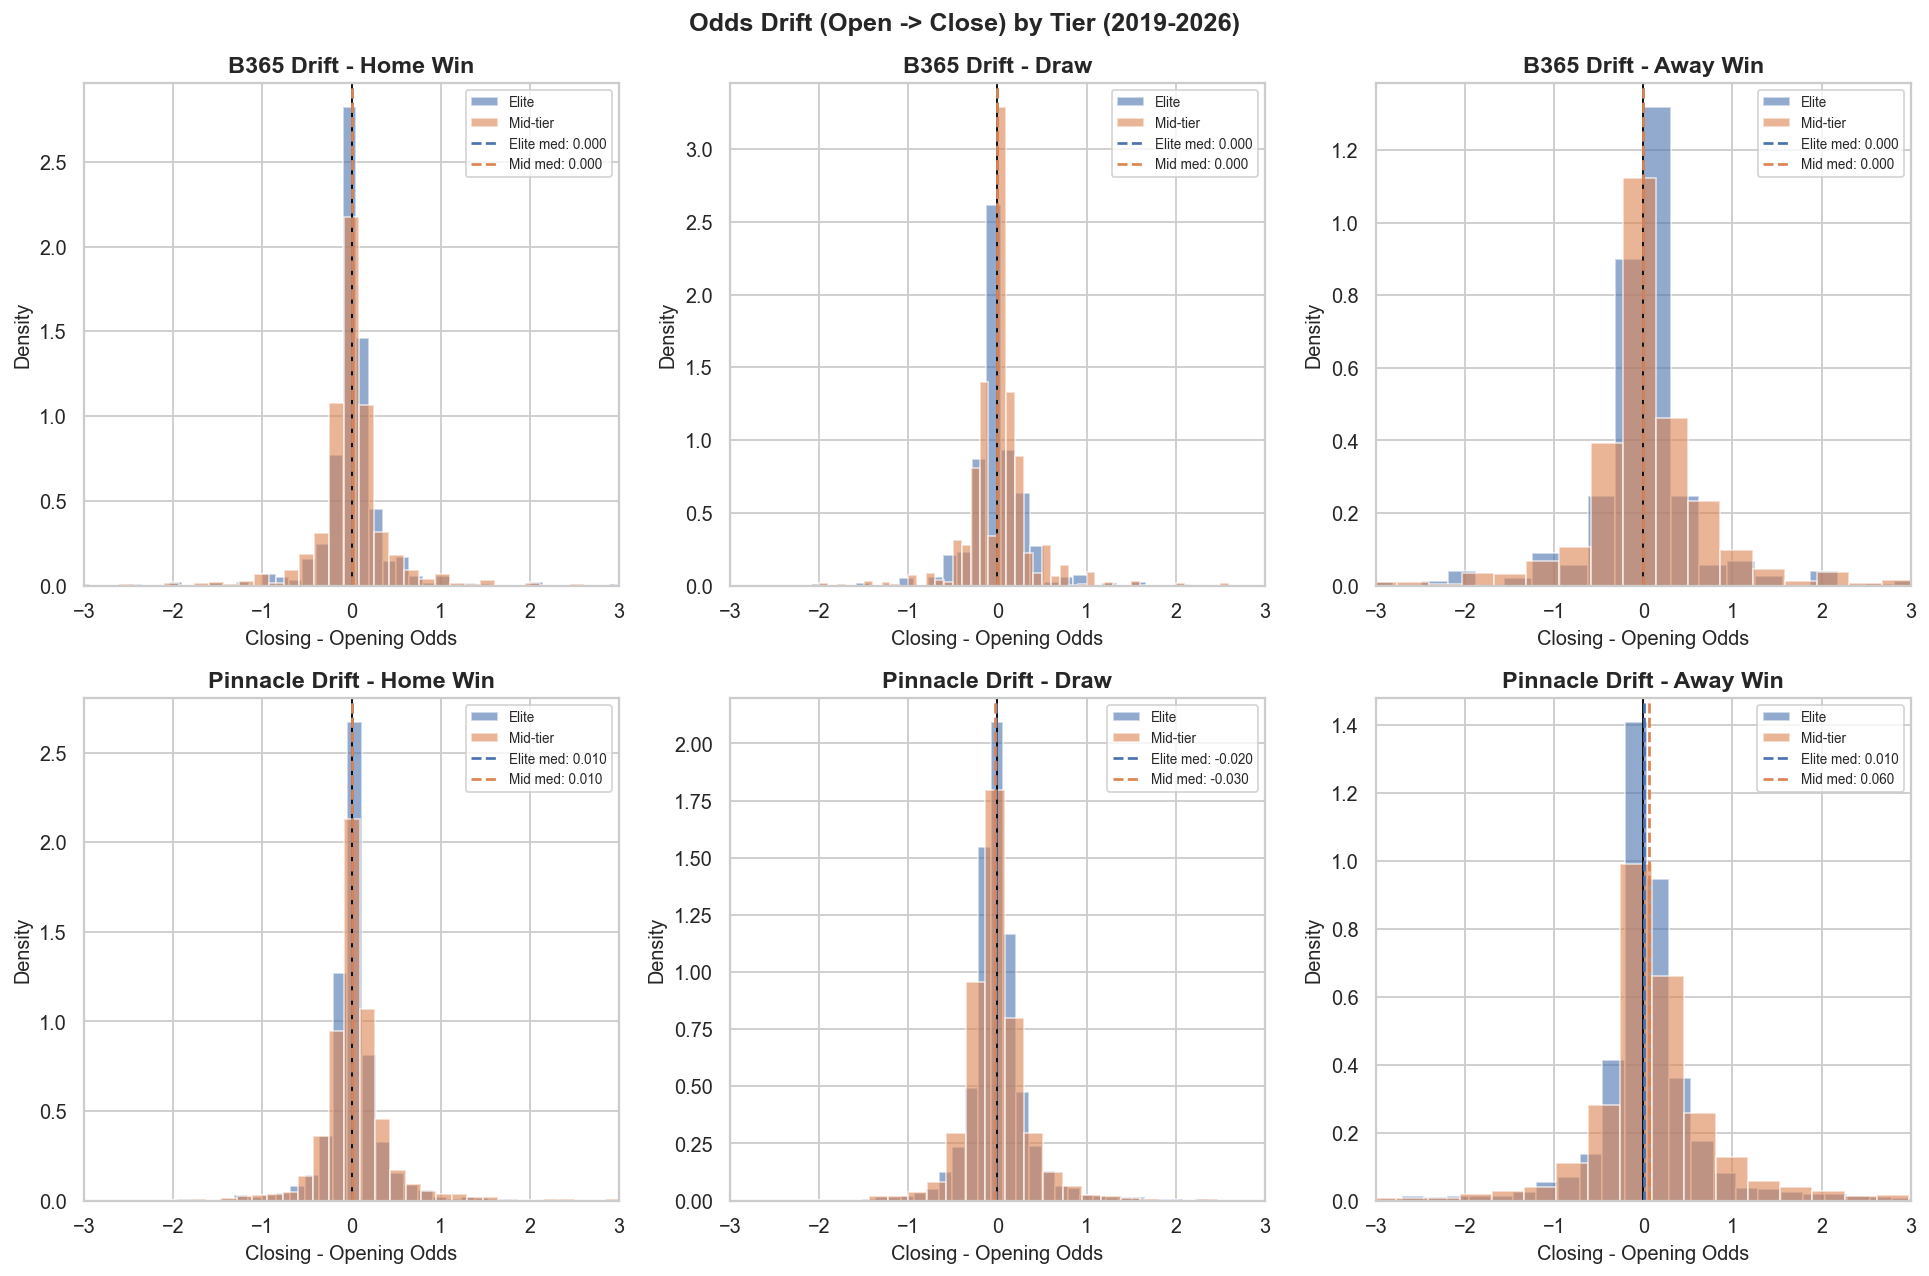

=== Drift Summary (median absolute drift) ===

Outcome    B365 Elite     B365 Mid     PS Elite       PS Mid
--------------------------------------------------------
Home           0.1000       0.1200       0.1000       0.1300
Draw           0.1000       0.1000       0.1200       0.1600
Away           0.1700       0.2500       0.1800       0.2600


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col_idx, outcome in enumerate(['H', 'D', 'A']):
    for row_idx, (bk, bk_label) in enumerate([('b365', 'B365'), ('pinnacle', 'Pinnacle')]):
        col = f'{bk}_drift_{outcome}'
        elite = master[master['tier'] == 'elite'][col].dropna()
        mid = master[master['tier'] == 'mid_tier'][col].dropna()
        ax = axes[row_idx, col_idx]
        ax.hist(elite, bins=80, alpha=0.6, color='#4C72B0', label='Elite', density=True)
        ax.hist(mid, bins=80, alpha=0.6, color='#DD8452', label='Mid-tier', density=True)
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.axvline(elite.median(), color='#4C72B0', linestyle='--', linewidth=1.5, label=f'Elite med: {elite.median():.3f}')
        ax.axvline(mid.median(), color='#DD8452', linestyle='--', linewidth=1.5, label=f'Mid med: {mid.median():.3f}')
        ax.set_title(f'{bk_label} Drift - {outcome_labels[outcome]}', fontweight='bold')
        ax.set_xlabel('Closing - Opening Odds'); ax.set_ylabel('Density')
        ax.legend(fontsize=7.5); ax.set_xlim(-3, 3)

fig.suptitle('Odds Drift (Open -> Close) by Tier (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_11_drift_by_tier.png', bbox_inches='tight')
plt.show()

print("=== Drift Summary (median absolute drift) ===\n")
print(f"{'Outcome':<8} {'B365 Elite':>12} {'B365 Mid':>12} {'PS Elite':>12} {'PS Mid':>12}")
print("-" * 56)
for outcome, label in zip(['H','D','A'], ['Home','Draw','Away']):
    b_e = master[master['tier']=='elite'][f'b365_drift_{outcome}'].abs().median()
    b_m = master[master['tier']=='mid_tier'][f'b365_drift_{outcome}'].abs().median()
    p_e = master[master['tier']=='elite'][f'pinnacle_drift_{outcome}'].abs().median()
    p_m = master[master['tier']=='mid_tier'][f'pinnacle_drift_{outcome}'].abs().median()
    print(f"{label:<8} {b_e:>12.4f} {b_m:>12.4f} {p_e:>12.4f} {p_m:>12.4f}")

**Observation (Drift by Tier):** Mid-tier away drift is ~47% wider than elite for both B365 (0.250 vs 0.170) and Pinnacle (0.260 vs 0.180). Non-zero Pinnacle medians confirm systematic sharp money activity, especially on mid-tier away outcomes. B365 median drift = 0 reflects price rounding, not true stasis.

### 7.2 Drift by league (Turkey vs Greece separation)

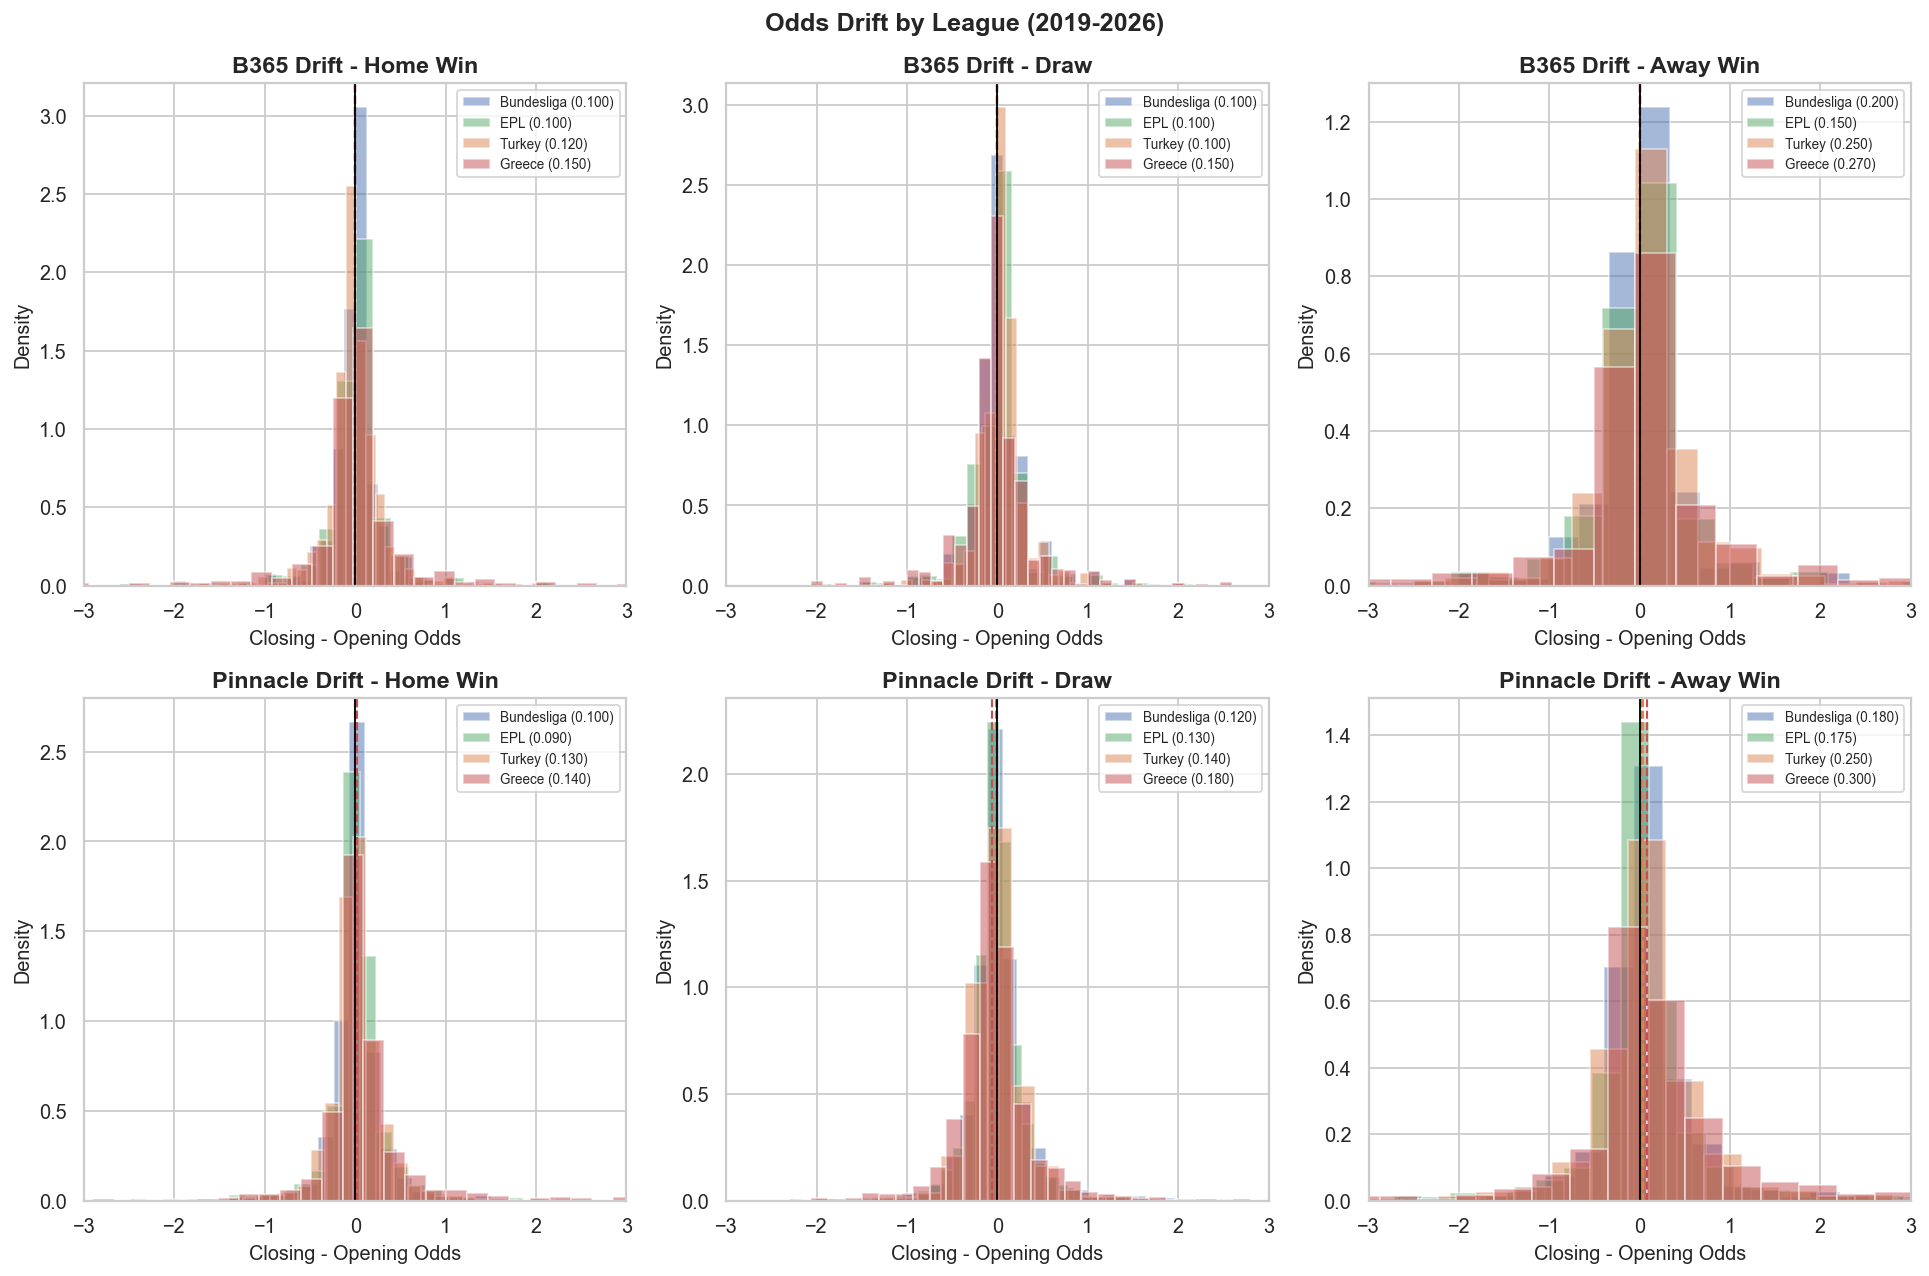

=== Absolute Median Drift by League ===

League         B365-H   B365-D   B365-A     PS-H     PS-D     PS-A
------------------------------------------------------------
Bundesliga      0.100    0.100    0.200    0.100    0.120    0.180
EPL             0.100    0.100    0.150    0.090    0.130    0.175
Turkey          0.120    0.100    0.250    0.130    0.140    0.250
Greece          0.150    0.150    0.270    0.140    0.180    0.300


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col_idx, outcome in enumerate(['H', 'D', 'A']):
    for row_idx, (bk, bk_label) in enumerate([('b365', 'B365'), ('pinnacle', 'Pinnacle')]):
        col = f'{bk}_drift_{outcome}'
        ax = axes[row_idx, col_idx]
        for league in ['D1', 'E0', 'T1', 'G1']:
            data = master[master['league'] == league][col].dropna()
            ax.hist(data, bins=60, alpha=0.5, density=True, color=league_colors[league],
                    label=f"{league_names[league]} ({data.abs().median():.3f})")
            ax.axvline(data.median(), color=league_colors[league], linestyle='--', linewidth=1.2)
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.set_title(f'{bk_label} Drift - {outcome_labels[outcome]}', fontweight='bold')
        ax.set_xlabel('Closing - Opening Odds'); ax.set_ylabel('Density')
        ax.legend(fontsize=7.5); ax.set_xlim(-3, 3)

fig.suptitle('Odds Drift by League (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_12_drift_by_league.png', bbox_inches='tight')
plt.show()

print("=== Absolute Median Drift by League ===\n")
print(f"{'League':<12} {'B365-H':>8} {'B365-D':>8} {'B365-A':>8} {'PS-H':>8} {'PS-D':>8} {'PS-A':>8}")
print("-" * 60)
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    row = [name]
    for bk in ['b365', 'pinnacle']:
        for outcome in ['H', 'D', 'A']:
            row.append(f"{master[master['league'] == league][f'{bk}_drift_{outcome}'].abs().median():.3f}")
    print(f"{row[0]:<12} {row[1]:>8} {row[2]:>8} {row[3]:>8} {row[4]:>8} {row[5]:>8} {row[6]:>8}")

**Observation (Drift by League):** Efficiency ranking EPL > Bundesliga > Turkey > Greece holds across all outcomes and both bookmakers. Greece's Pinnacle away drift (0.300) is the highest value in the dataset — 71% wider than EPL (0.175). Turkey and Greece separate meaningfully on Pinnacle drift (0.250 vs 0.300), confirming Greece as least efficient.

### 7.3 Opening vs closing spread comparison

Does bookmaker disagreement increase or decrease from open to close? Efficient markets should converge as kickoff approaches; widening is unusual.

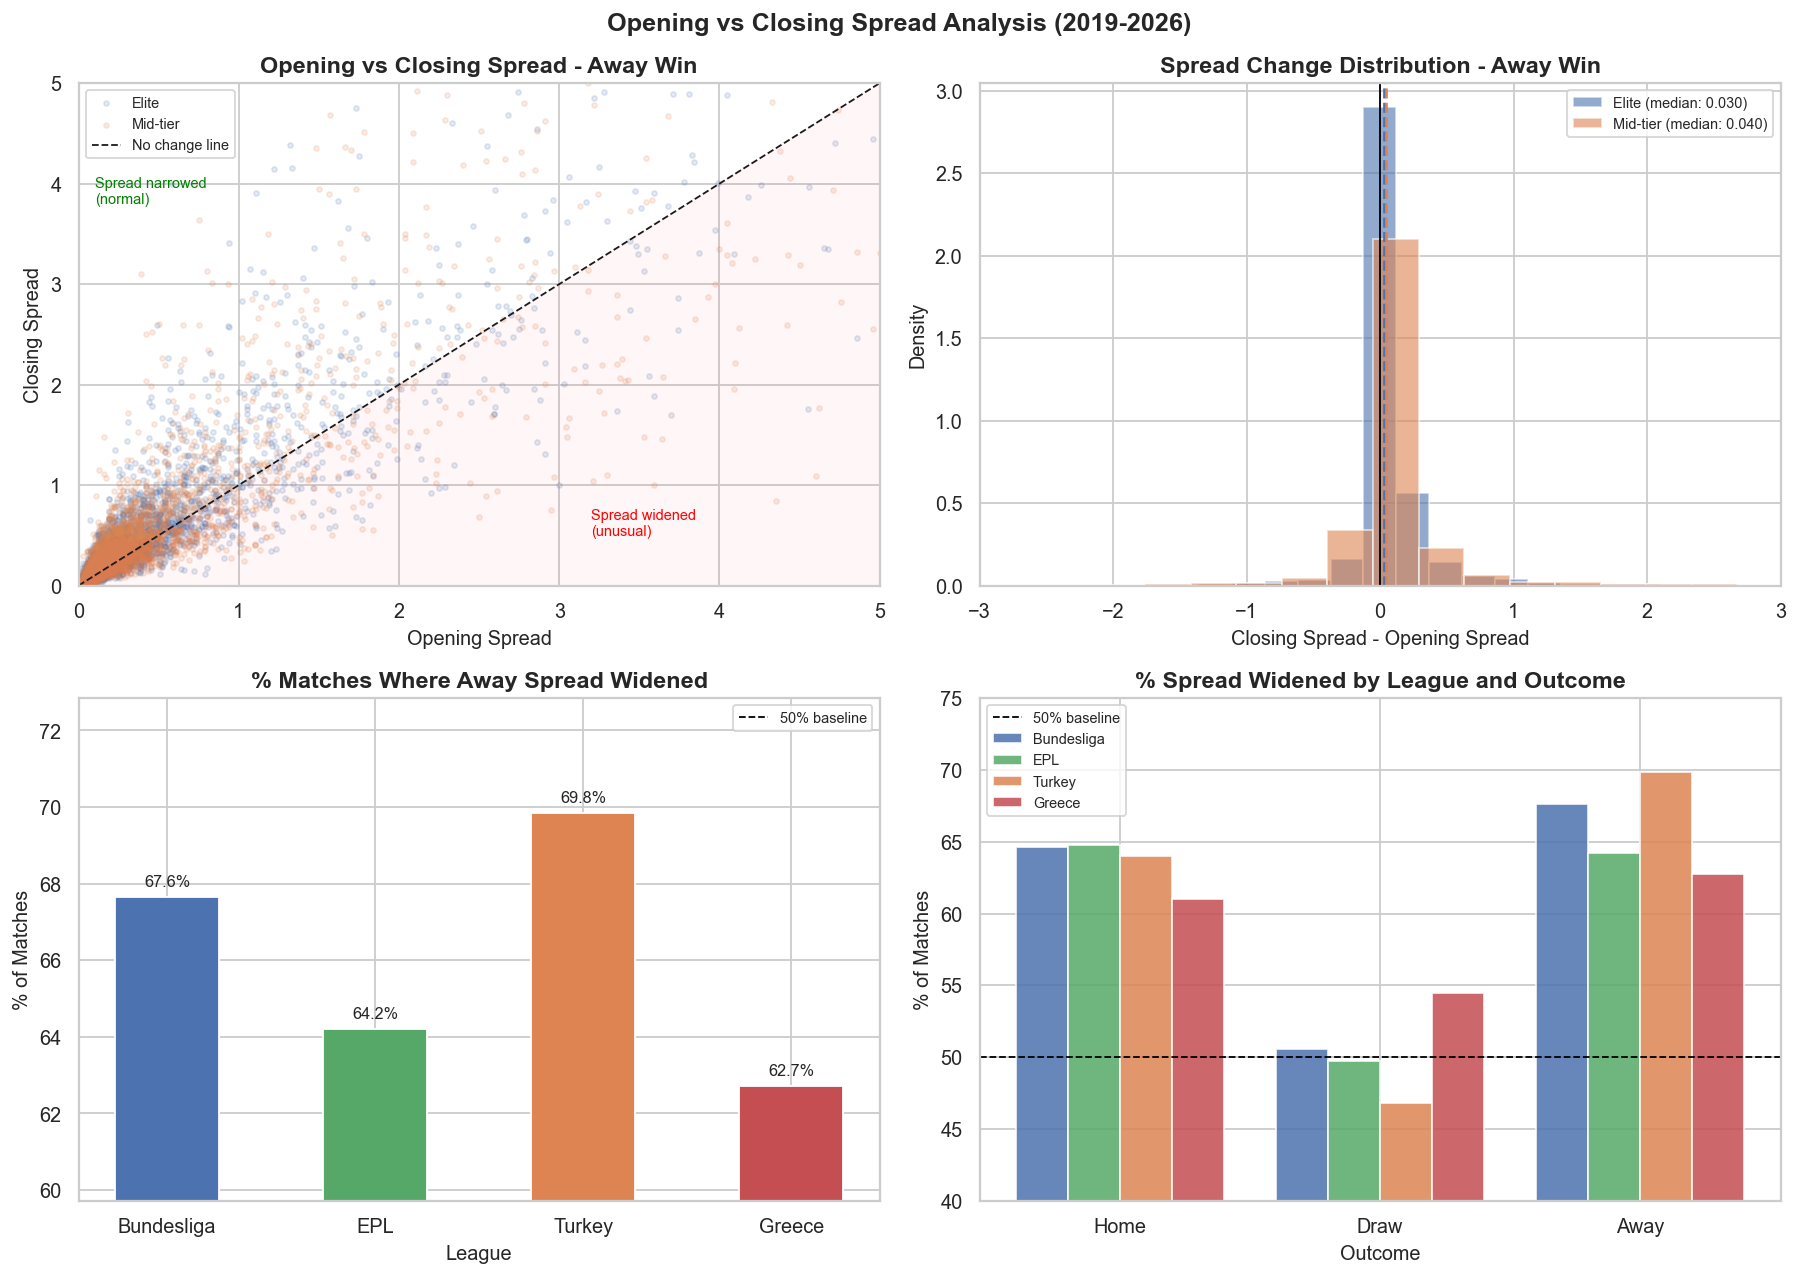

=== % Matches Where Spread Widened - All Outcomes ===

League           Home     Draw     Away
------------------------------------
Bundesliga      64.7%    50.6%    67.6%
EPL             64.8%    49.7%    64.2%
Turkey          64.0%    46.8%    69.8%
Greece          61.0%    54.4%    62.7%


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - scatter opening vs closing (away)
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    sub = master[master['tier'] == tier]
    axes[0,0].scatter(sub['opening_spread_A'], sub['closing_spread_A'], alpha=0.15, s=8, color=color, label=label)
axes[0,0].plot([0,10],[0,10], 'k--', linewidth=1, label='No change line')
axes[0,0].set_xlim(0, 5); axes[0,0].set_ylim(0, 5)
axes[0,0].set_title('Opening vs Closing Spread - Away Win', fontweight='bold')
axes[0,0].set_xlabel('Opening Spread'); axes[0,0].set_ylabel('Closing Spread')
axes[0,0].legend(fontsize=8, loc='upper left')
axes[0,0].fill_between([0,5],[0,0],[0,5], alpha=0.03, color='red')
axes[0,0].text(3.2, 0.5, 'Spread widened\n(unusual)', fontsize=8, color='red')
axes[0,0].text(0.1, 3.8, 'Spread narrowed\n(normal)', fontsize=8, color='green')

# Chart 2 - spread change distribution
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    data = master[master['tier'] == tier]['spread_change_A'].dropna()
    axes[0,1].hist(data, bins=80, alpha=0.6, density=True, color=color, label=f'{label} (median: {data.median():.3f})')
    axes[0,1].axvline(data.median(), color=color, linestyle='--', linewidth=1.5)
axes[0,1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0,1].set_title('Spread Change Distribution - Away Win', fontweight='bold')
axes[0,1].set_xlabel('Closing Spread - Opening Spread'); axes[0,1].set_ylabel('Density')
axes[0,1].legend(fontsize=8); axes[0,1].set_xlim(-3, 3)

# Chart 3 - % widened by league (away)
pct_data = {name: (master[master['league']==lg]['spread_change_A'] > 0).mean() * 100
            for lg, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece'])}
bars = axes[1,0].bar(pct_data.keys(), pct_data.values(), color=lc, width=0.5)
axes[1,0].axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[1,0].set_ylim(min(pct_data.values())-3, max(pct_data.values())+3)
axes[1,0].set_title('% Matches Where Away Spread Widened', fontweight='bold')
axes[1,0].set_xlabel('League'); axes[1,0].set_ylabel('% of Matches')
axes[1,0].legend(fontsize=8)
for bar, val in zip(bars, pct_data.values()):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 4 - % widened by league and outcome
x = range(3); width = 0.2
for i, (lg, name, color) in enumerate(zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece'], lc)):
    pcts = [(master[master['league']==lg][f'spread_change_{o}'] > 0).mean()*100 for o in ['H','D','A']]
    axes[1,1].bar([xi + i*width for xi in x], pcts, width, label=name, color=color, alpha=0.85)
axes[1,1].axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[1,1].set_ylim(40, 75)
axes[1,1].set_title('% Spread Widened by League and Outcome', fontweight='bold')
axes[1,1].set_xlabel('Outcome'); axes[1,1].set_ylabel('% of Matches')
axes[1,1].set_xticks([xi + 1.5*width for xi in x]); axes[1,1].set_xticklabels(['Home','Draw','Away'])
axes[1,1].legend(fontsize=8)

fig.suptitle('Opening vs Closing Spread Analysis (2019-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_13_spread_change.png', bbox_inches='tight')
plt.show()

print("=== % Matches Where Spread Widened - All Outcomes ===\n")
print(f"{'League':<12} {'Home':>8} {'Draw':>8} {'Away':>8}")
print("-" * 36)
for lg, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    pcts = [(master[master['league']==lg][f'spread_change_{o}'] > 0).mean()*100 for o in ['H','D','A']]
    print(f"{name:<12} {pcts[0]:>7.1f}% {pcts[1]:>7.1f}% {pcts[2]:>7.1f}%")

**Observation (Opening vs Closing Spread):** Spreads widen from open to close in most matches — 63–70% for away, ~64% for home, ~50% for draws — counter to the expected convergence. Turkey has the highest away widening rate (69.8%) and largest median change; Greece starts wide and stays wide. Draw spread widening reveals the sharpest league divergence: Turkey converges (46.8%) while Greece diverges (54.5%) — a reversal of the usual Turkey/Greece ranking that warrants attention in the modeling phase.

## Pinnacle findings

## 8. Pinnacle vs Bet365 — Sharp vs Recreational Bookmaker

Pinnacle is the sharpest bookmaker in the market — it welcomes professional bettors, accepts high limits, and runs low margins. Bet365 is a recreational-facing book that limits winners and runs higher margins. This section compares their accuracy directly to show why bookmaker *type* matters for market efficiency.

All analysis uses **closing odds** — each bookmaker's final, best estimate before kickoff.
Only matches where both bookmakers priced the game are included (fair head-to-head).

### 8.1 Setup — normalised closing probabilities for both bookmakers

In [38]:
# Fair comparison: only matches where BOTH bookmakers have closing odds
cmp = master.dropna(subset=['B365CH','B365CD','B365CA','PSCH','PSCD','PSCA']).copy()

def normalised_probs(df, h, d, a):
    """Strip margin: normalise 1/odds so H+D+A = 1.0"""
    raw_h, raw_d, raw_a = 1/df[h], 1/df[d], 1/df[a]
    total = raw_h + raw_d + raw_a
    return raw_h/total, raw_d/total, raw_a/total

cmp['b365_ph'], cmp['b365_pd'], cmp['b365_pa'] = normalised_probs(cmp,'B365CH','B365CD','B365CA')
cmp['pinn_ph'], cmp['pinn_pd'], cmp['pinn_pa'] = normalised_probs(cmp,'PSCH','PSCD','PSCA')

print(f"Matches with both bookmakers: {len(cmp):,}")
print(f"\nSample size by league:")
print(cmp.groupby('league').size())
print(f"\nNote: ~50% of 2025/26 excluded due to Pinnacle upload lag.")

Matches with both bookmakers: 8,235

Sample size by league:
league
D1    1985
E0    2490
G1    1485
T1    2275
dtype: int64

Note: ~50% of 2025/26 excluded due to Pinnacle upload lag.


### 8.2 Actual result vs Bet365 vs Pinnacle predicted (the headline chart)

For each league and outcome, compare the actual result rate against what each bookmaker's
closing odds predicted. The bookmaker whose bars sit closest to "Actual" is more accurate.

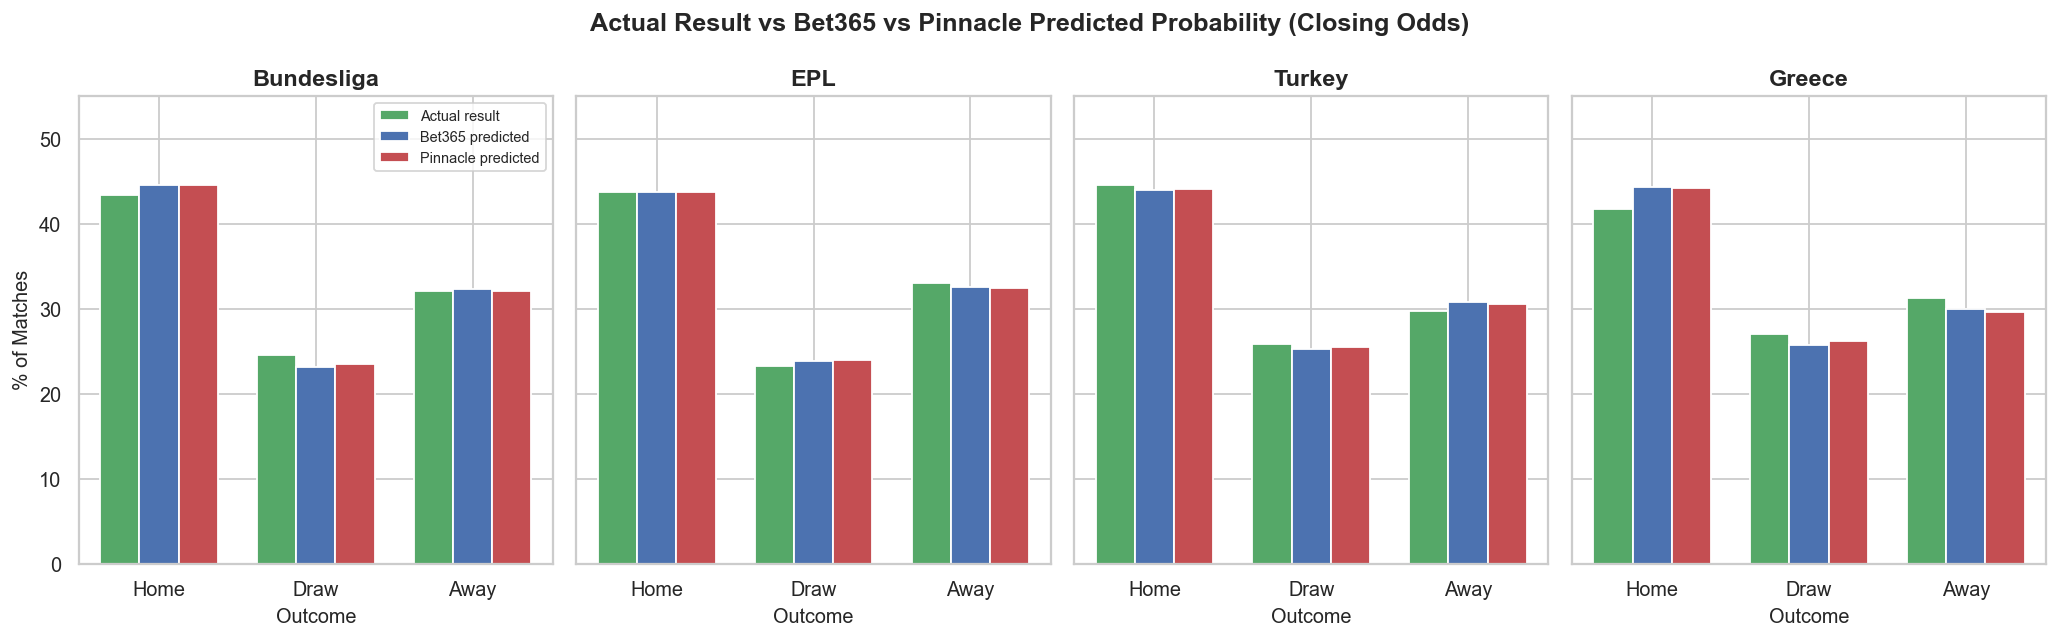

In [41]:
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
outcomes = ['H', 'D', 'A']
x = np.arange(3)
width = 0.25

for ax, lg in zip(axes, ['D1','E0','T1','G1']):
    sub = cmp[cmp['league'] == lg]
    actual = [(sub['FTR']==o).mean()*100 for o in outcomes]
    b365 = [sub[c].mean()*100 for c in ['b365_ph','b365_pd','b365_pa']]
    pinn = [sub[c].mean()*100 for c in ['pinn_ph','pinn_pd','pinn_pa']]

    ax.bar(x - width, actual, width, label='Actual result', color='#55A868')
    ax.bar(x, b365, width, label='Bet365 predicted', color='#4C72B0')
    ax.bar(x + width, pinn, width, label='Pinnacle predicted', color='#C44E52')
    ax.set_title(league_names[lg], fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Home', 'Draw', 'Away'])
    ax.set_xlabel('Outcome')
    ax.set_ylim(0, 55)

axes[0].set_ylabel('% of Matches')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Actual Result vs Bet365 vs Pinnacle Predicted Probability (Closing Odds)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/fig_14_pinnacle_vs_b365_predicted.png', bbox_inches='tight')
plt.show()

### 8.3 Brier score — single-number accuracy comparison

The Brier score measures forecast accuracy: for each match, sum the squared error between
predicted probability and actual outcome (1/0) across all three outcomes, then average.
**Lower = more accurate.** This amplifies the small visual differences into a comparable metric.

In [42]:
def brier(df, ph, pd_, pa):
    oh = (df['FTR']=='H').astype(int)
    od = (df['FTR']=='D').astype(int)
    oa = (df['FTR']=='A').astype(int)
    return ((df[ph]-oh)**2 + (df[pd_]-od)**2 + (df[pa]-oa)**2).mean()

print("=== Brier Score by League (lower = more accurate) ===\n")
print(f"{'League':<12} {'Bet365':>10} {'Pinnacle':>10} {'Pinnacle better by':>20}")
print("-" * 54)

brier_rows = []
for lg in ['D1','E0','T1','G1']:
    sub = cmp[cmp['league']==lg]
    b = brier(sub,'b365_ph','b365_pd','b365_pa')
    p = brier(sub,'pinn_ph','pinn_pd','pinn_pa')
    pct = (b - p) / b * 100
    brier_rows.append({'league': league_names[lg], 'b365': b, 'pinnacle': p, 'gap_pct': pct})
    print(f"{league_names[lg]:<12} {b:>10.4f} {p:>10.4f} {pct:>19.1f}%")

b_all = brier(cmp,'b365_ph','b365_pd','b365_pa')
p_all = brier(cmp,'pinn_ph','pinn_pd','pinn_pa')
print("-" * 54)
print(f"{'OVERALL':<12} {b_all:>10.4f} {p_all:>10.4f} {(b_all-p_all)/b_all*100:>19.1f}%")

brier_df = pd.DataFrame(brier_rows)

=== Brier Score by League (lower = more accurate) ===

League           Bet365   Pinnacle   Pinnacle better by
------------------------------------------------------
Bundesliga       0.5787     0.5784                 0.0%
EPL              0.5675     0.5677                -0.0%
Turkey           0.5816     0.5797                 0.3%
Greece           0.5592     0.5560                 0.6%
------------------------------------------------------
OVERALL          0.5726     0.5715                 0.2%


### 8.4 Overlaid calibration curves — Pinnacle vs Bet365

The same calibration test from Section 6.2, run for both bookmakers and overlaid.
The line that hugs the diagonal more tightly is the better-calibrated forecaster.

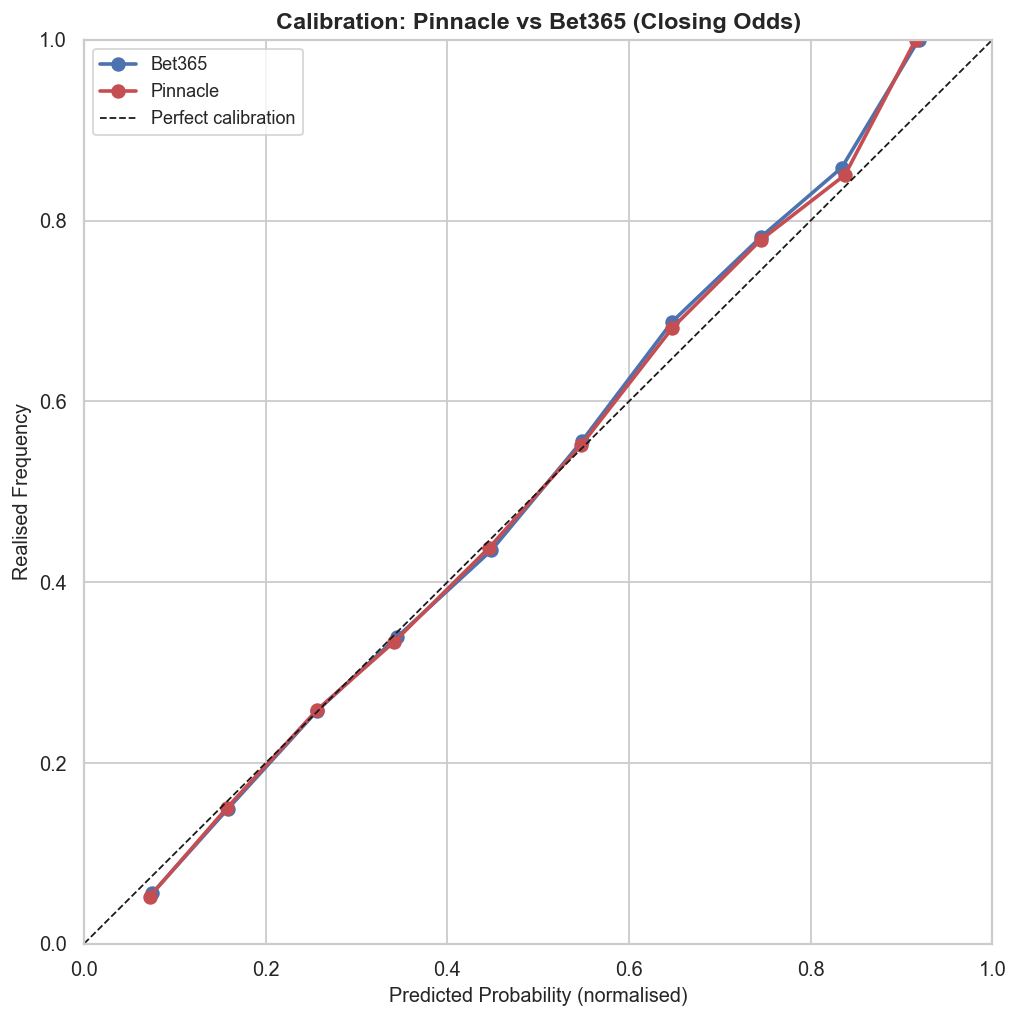

In [43]:
# Build long-format frames for both bookmakers
def build_long(df, h, d, a):
    rows = []
    for _, r in df.iterrows():
        raw = {'H': 1/r[h], 'D': 1/r[d], 'A': 1/r[a]}
        total = sum(raw.values())
        for oc in ['H','D','A']:
            rows.append({'implied_norm': raw[oc]/total, 'occurred': int(r['FTR']==oc)})
    return pd.DataFrame(rows)

b365_long = build_long(cmp, 'B365CH','B365CD','B365CA')
pinn_long = build_long(cmp, 'PSCH','PSCD','PSCA')

bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
bin_centers = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]

fig, ax = plt.subplots(figsize=(8, 8))

for long_df, name, color in [(b365_long,'Bet365','#4C72B0'), (pinn_long,'Pinnacle','#C44E52')]:
    long_df = long_df.copy()
    long_df['bucket'] = pd.cut(long_df['implied_norm'], bins=bins, labels=bin_centers)
    grouped = long_df.groupby('bucket', observed=True).agg(
        predicted=('implied_norm','mean'), realised=('occurred','mean')).dropna()
    ax.plot(grouped['predicted'], grouped['realised'], marker='o',
            color=color, label=name, linewidth=2, markersize=7)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_title('Calibration: Pinnacle vs Bet365 (Closing Odds)', fontweight='bold')
ax.set_xlabel('Predicted Probability (normalised)')
ax.set_ylabel('Realised Frequency')
ax.legend(fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig('../data/figures/fig_15_calibration_pinnacle_vs_b365.png', bbox_inches='tight')
plt.show()

### 8.5 Margin comparison — why the business models differ

Pinnacle runs a low-margin, high-volume model (welcomes sharps); Bet365 runs higher margins
(limits sharps). This shows how much extra recreational bettors pay per league.

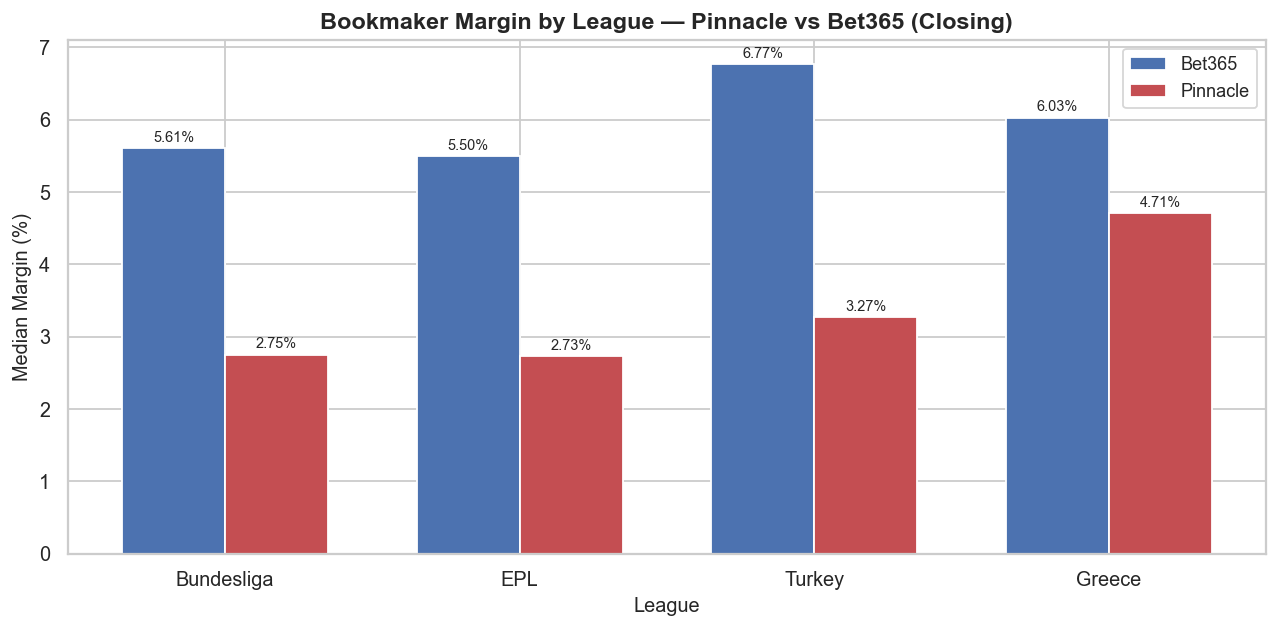

=== Median Margin by League ===

League           Bet365   Pinnacle   Difference
----------------------------------------------
Bundesliga        5.61%      2.75%        2.86pp
EPL               5.50%      2.73%        2.77pp
Turkey            6.77%      3.27%        3.50pp
Greece            6.03%      4.71%        1.32pp


In [44]:
cmp['b365_overround'] = 1/cmp['B365CH'] + 1/cmp['B365CD'] + 1/cmp['B365CA']
cmp['pinn_overround'] = 1/cmp['PSCH'] + 1/cmp['PSCD'] + 1/cmp['PSCA']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.35

b365_margins = [(cmp[cmp['league']==lg]['b365_overround'].median()-1)*100 for lg in ['D1','E0','T1','G1']]
pinn_margins = [(cmp[cmp['league']==lg]['pinn_overround'].median()-1)*100 for lg in ['D1','E0','T1','G1']]

bars1 = ax.bar(x - width/2, b365_margins, width, label='Bet365', color='#4C72B0')
bars2 = ax.bar(x + width/2, pinn_margins, width, label='Pinnacle', color='#C44E52')

for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Bookmaker Margin by League — Pinnacle vs Bet365 (Closing)', fontweight='bold')
ax.set_xlabel('League'); ax.set_ylabel('Median Margin (%)')
ax.set_xticks(x); ax.set_xticklabels(['Bundesliga','EPL','Turkey','Greece'])
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/figures/fig_16_margin_pinnacle_vs_b365.png', bbox_inches='tight')
plt.show()

print("=== Median Margin by League ===\n")
print(f"{'League':<12} {'Bet365':>10} {'Pinnacle':>10} {'Difference':>12}")
print("-" * 46)
for lg, b, p in zip(['Bundesliga','EPL','Turkey','Greece'], b365_margins, pinn_margins):
    print(f"{lg:<12} {b:>9.2f}% {p:>9.2f}% {b-p:>11.2f}pp")

### 8.6 Opening odds — does Pinnacle's edge show up before the close?

Closing lines converge as information arrives, so the two bookmakers looked nearly identical
in 8.2–8.4. Opening odds are set days before kickoff, before the market has been tested —
this is where a sharp bookmaker's edge should be most visible. We repeat the accuracy
comparison on opening odds (`B365H/D/A` and `PSH/D/A`).

In [45]:
# Opening-odds comparison frame (both bookmakers' opening odds present)
cmp_o = master.dropna(subset=['B365H','B365D','B365A','PSH','PSD','PSA']).copy()

cmp_o['b365_ph'], cmp_o['b365_pd'], cmp_o['b365_pa'] = normalised_probs(cmp_o,'B365H','B365D','B365A')
cmp_o['pinn_ph'], cmp_o['pinn_pd'], cmp_o['pinn_pa'] = normalised_probs(cmp_o,'PSH','PSD','PSA')

print(f"Matches with both bookmakers' opening odds: {len(cmp_o):,}")
print(f"\nSample size by league:")
print(cmp_o.groupby('league').size())

Matches with both bookmakers' opening odds: 8,175

Sample size by league:
league
D1    1986
E0    2490
G1    1443
T1    2256
dtype: int64


### 8.7 Total predicted vs realised — all leagues combined (opening + closing)

A single-panel view aggregating all four leagues. Shows the overall accuracy picture
without per-league breakdown — useful as a summary slide.

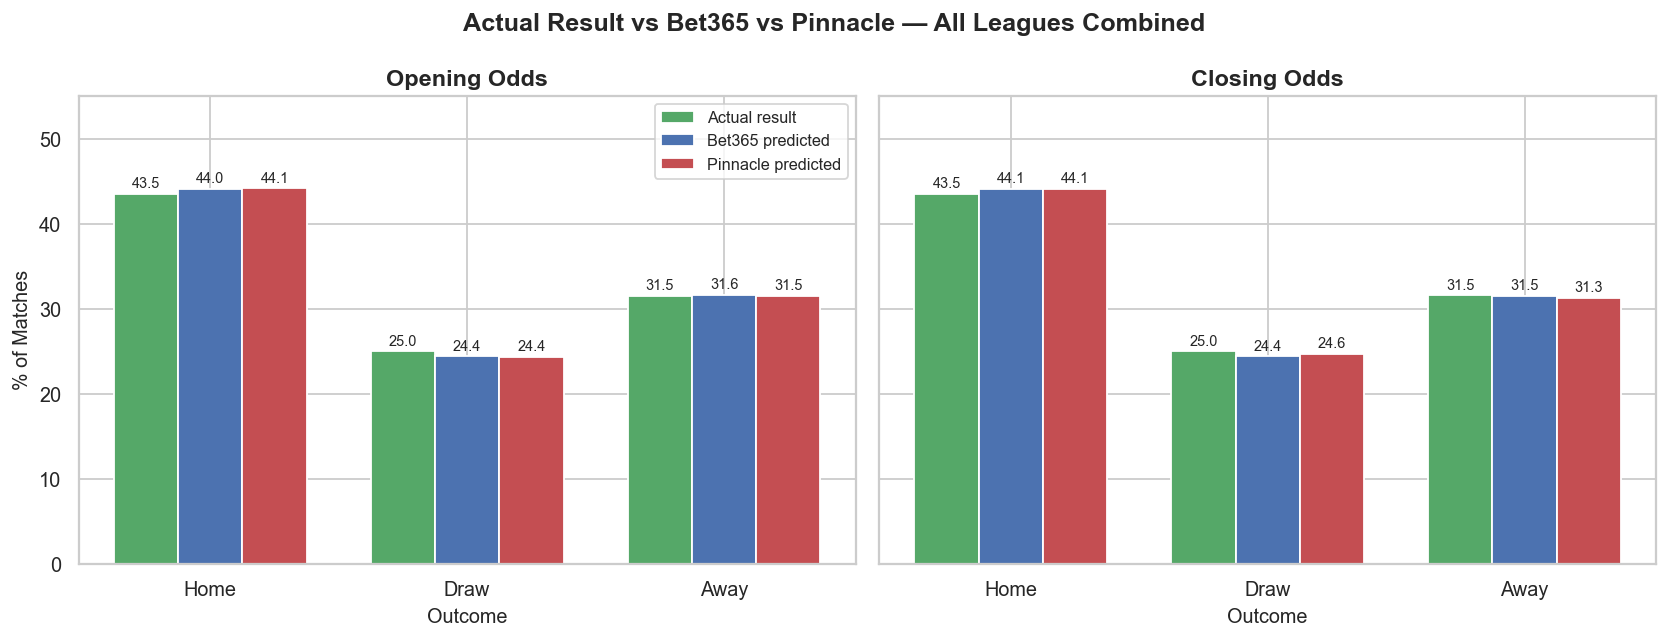

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
outcomes = ['H', 'D', 'A']
x = np.arange(3)
width = 0.25

def label_bars(ax, bars):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# Left: opening odds
a_o = [(cmp_o['FTR']==o).mean()*100 for o in outcomes]
b_o = [cmp_o[c].mean()*100 for c in ['b365_ph','b365_pd','b365_pa']]
p_o = [cmp_o[c].mean()*100 for c in ['pinn_ph','pinn_pd','pinn_pa']]
bars_a = axes[0].bar(x-width, a_o, width, label='Actual result', color='#55A868')
bars_b = axes[0].bar(x, b_o, width, label='Bet365 predicted', color='#4C72B0')
bars_p = axes[0].bar(x+width, p_o, width, label='Pinnacle predicted', color='#C44E52')
for bars in (bars_a, bars_b, bars_p):
    label_bars(axes[0], bars)
axes[0].set_title('Opening Odds', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Home','Draw','Away'])
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('% of Matches')
axes[0].set_ylim(0, 55); axes[0].legend(fontsize=9)

# Right: closing odds (cmp from 8.1)
a_c = [(cmp['FTR']==o).mean()*100 for o in outcomes]
b_c = [cmp[c].mean()*100 for c in ['b365_ph','b365_pd','b365_pa']]
p_c = [cmp[c].mean()*100 for c in ['pinn_ph','pinn_pd','pinn_pa']]
bars_a2 = axes[1].bar(x-width, a_c, width, label='Actual result', color='#55A868')
bars_b2 = axes[1].bar(x, b_c, width, label='Bet365 predicted', color='#4C72B0')
bars_p2 = axes[1].bar(x+width, p_c, width, label='Pinnacle predicted', color='#C44E52')
for bars in (bars_a2, bars_b2, bars_p2):
    label_bars(axes[1], bars)
axes[1].set_title('Closing Odds', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Home','Draw','Away'])
axes[1].set_xlabel('Outcome')
axes[1].set_ylim(0, 55)

fig.suptitle('Actual Result vs Bet365 vs Pinnacle — All Leagues Combined', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/fig_17_pinnacle_total_open_close.png', bbox_inches='tight')
plt.show()

### 8.8 Predicted vs realised by league — opening odds

The same per-league chart as 8.2, but using opening odds. Compare against 8.2 to see
whether the bookmakers diverge more before the market has converged.

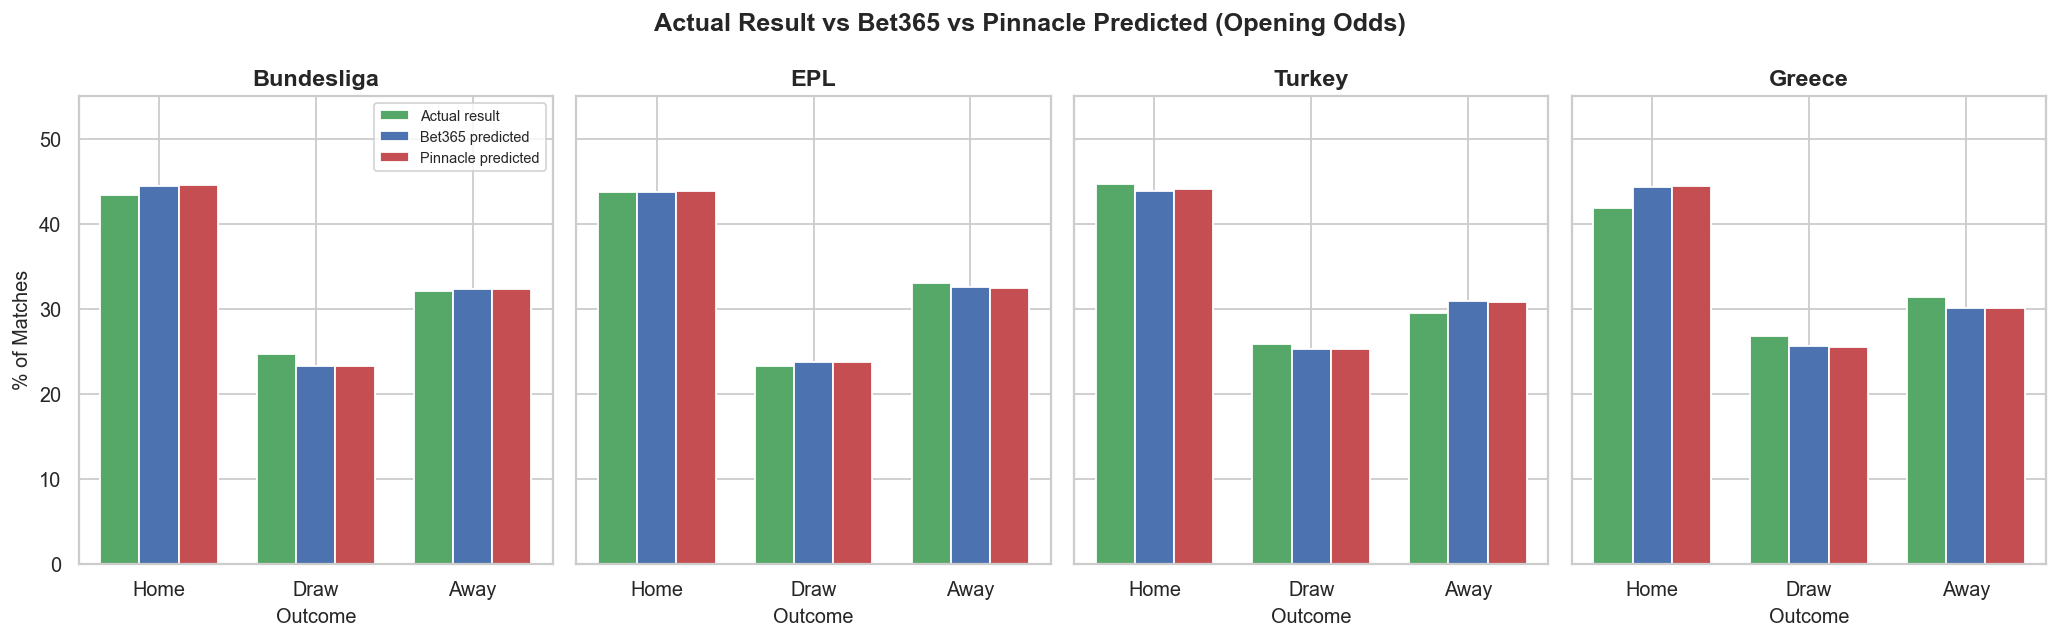

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
x = np.arange(3)
width = 0.25

for ax, lg in zip(axes, ['D1','E0','T1','G1']):
    sub = cmp_o[cmp_o['league'] == lg]
    actual = [(sub['FTR']==o).mean()*100 for o in outcomes]
    b365 = [sub[c].mean()*100 for c in ['b365_ph','b365_pd','b365_pa']]
    pinn = [sub[c].mean()*100 for c in ['pinn_ph','pinn_pd','pinn_pa']]
    ax.bar(x - width, actual, width, label='Actual result', color='#55A868')
    ax.bar(x, b365, width, label='Bet365 predicted', color='#4C72B0')
    ax.bar(x + width, pinn, width, label='Pinnacle predicted', color='#C44E52')
    ax.set_title(league_names[lg], fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(['Home','Draw','Away'])
    ax.set_xlabel('Outcome'); ax.set_ylim(0, 55)

axes[0].set_ylabel('% of Matches')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Actual Result vs Bet365 vs Pinnacle Predicted (Opening Odds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/fig_18_pinnacle_vs_b365_predicted_opening.png', bbox_inches='tight')
plt.show()

### 8.9 Brier score — opening odds

The accuracy comparison on opening odds. If Pinnacle is genuinely sharper, the gap should
be larger here than at the close (where both books converge).

In [49]:
print("=== Brier Score by League — OPENING odds (lower = more accurate) ===\n")
print(f"{'League':<12} {'Bet365':>10} {'Pinnacle':>10} {'Pinnacle better by':>20}")
print("-" * 54)

for lg in ['D1','E0','T1','G1']:
    sub = cmp_o[cmp_o['league']==lg]
    b = brier(sub,'b365_ph','b365_pd','b365_pa')
    p = brier(sub,'pinn_ph','pinn_pd','pinn_pa')
    print(f"{league_names[lg]:<12} {b:>10.4f} {p:>10.4f} {(b-p)/b*100:>19.1f}%")

b_all = brier(cmp_o,'b365_ph','b365_pd','b365_pa')
p_all = brier(cmp_o,'pinn_ph','pinn_pd','pinn_pa')
print("-" * 54)
print(f"{'OVERALL':<12} {b_all:>10.4f} {p_all:>10.4f} {(b_all-p_all)/b_all*100:>19.1f}%")

print("\n(Compare to closing-odds Brier in 8.3 — a larger opening gap means Pinnacle's")
print(" edge erodes as Bet365 converges toward the sharp price by kickoff.)")

=== Brier Score by League — OPENING odds (lower = more accurate) ===

League           Bet365   Pinnacle   Pinnacle better by
------------------------------------------------------
Bundesliga       0.5799     0.5799                 0.0%
EPL              0.5708     0.5705                 0.0%
Turkey           0.5847     0.5829                 0.3%
Greece           0.5599     0.5579                 0.4%
------------------------------------------------------
OVERALL          0.5749     0.5740                 0.2%

(Compare to closing-odds Brier in 8.3 — a larger opening gap means Pinnacle's
 edge erodes as Bet365 converges toward the sharp price by kickoff.)


### 8.10 Calibration curve — opening odds

Overlaid calibration for both bookmakers on opening odds. Compare to the closing-odds
calibration in 8.4.

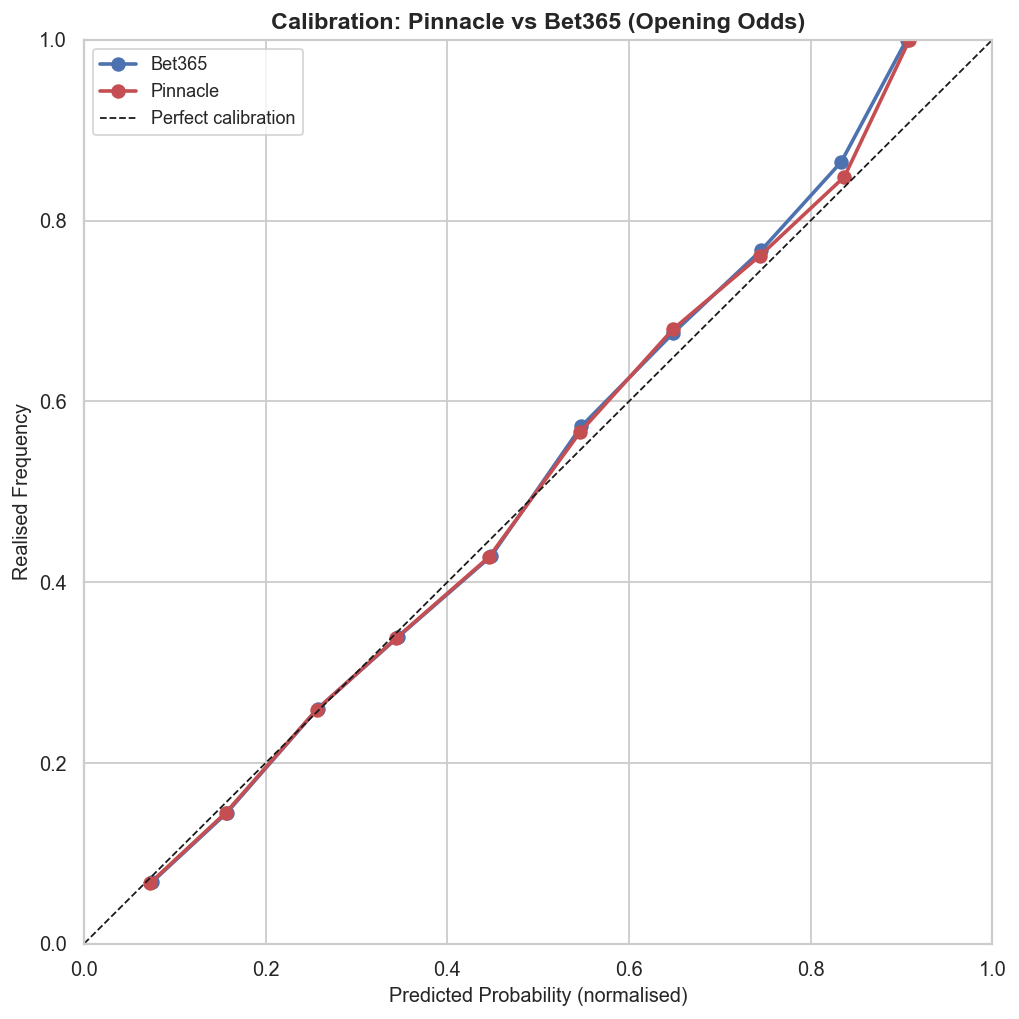

In [50]:
b365_long_o = build_long(cmp_o, 'B365H','B365D','B365A')
pinn_long_o = build_long(cmp_o, 'PSH','PSD','PSA')

bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
bin_centers = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]

fig, ax = plt.subplots(figsize=(8, 8))

for long_df, name, color in [(b365_long_o,'Bet365','#4C72B0'), (pinn_long_o,'Pinnacle','#C44E52')]:
    long_df = long_df.copy()
    long_df['bucket'] = pd.cut(long_df['implied_norm'], bins=bins, labels=bin_centers)
    grouped = long_df.groupby('bucket', observed=True).agg(
        predicted=('implied_norm','mean'), realised=('occurred','mean')).dropna()
    ax.plot(grouped['predicted'], grouped['realised'], marker='o',
            color=color, label=name, linewidth=2, markersize=7)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_title('Calibration: Pinnacle vs Bet365 (Opening Odds)', fontweight='bold')
ax.set_xlabel('Predicted Probability (normalised)')
ax.set_ylabel('Realised Frequency')
ax.legend(fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig('../data/figures/fig_19_calibration_pinnacle_vs_b365_opening.png', bbox_inches='tight')
plt.show()

### 8.11 Pinnacle section summary

**Context:** Pinnacle is the sharpest bookmaker in the market (welcomes professional bettors, high limits, low margins). Bet365 is recreational-facing (limits winners, higher margins). This section compared the two directly to demonstrate how bookmaker *type* relates to market efficiency.

**Key findings:**

| # | Finding | Takeaway |
|---|---|---|
| 1 | Closing-odds accuracy near-identical (Brier: Pinnacle 0.5715 vs Bet365 0.5726, +0.2%) | By kickoff both books converge — accuracy is not where they differ |
| 2 | Opening-odds accuracy also near-identical (+0.2% overall) | Bet365's opening prices already track the sharp line — mature market |
| 3 | Pinnacle's small edge lives only in mid-tier leagues (Greece +0.4–0.6%, Turkey +0.3%; elite 0.0%) | Sharp/recreational gap surfaces only where markets are less efficient — reinforces H1 |
| 4 | Both books well-calibrated at open and close (curves nearly overlap) | Neither systematically mis-prices; shared favourite-longshot S-curve |
| 5 | Bet365 charges ~2x Pinnacle's margin in 3 of 4 leagues (e.g. Turkey 6.77% vs 3.27%) | The decisive difference between the books is margin, not accuracy |
| 6 | Greece anomaly: even Pinnacle's margin is elevated (4.71% vs ~2.7–3.3% elsewhere) | When the sharpest book widens its own margin for a league, that league is genuinely hard to price — independent confirmation of Greece as least efficient |

**Bottom line:** The textbook claim "Pinnacle is more accurate than Bet365" does **not** hold strongly at the closing or opening line for these leagues — both are well-calibrated and nearly equally accurate. The real, defensible distinction is **margin** (Bet365 charges roughly double) and the **mid-tier concentration** of Pinnacle's marginal edge. The standout result is Greece, where even Pinnacle prices in a risk premium — an independent signal, separate from spread and drift, that Greece is the least efficient and highest-risk market in the dataset.

**Caveat:** Brier differences of ~0.2% on a base of ~0.57 are marginal and should be reported as "slightly sharper," not "more accurate." Accuracy claims are deliberately understated to preserve credibility.

## 9. EDA Complete Summary

Consolidated findings across all analytical sections and the final dataset save.

### 9.1 Findinds table

In [51]:
summary = {
    'Finding': [
        'Mid-tier away spread 43% wider than elite',
        'Mid-tier bookmaker margin 29% higher than elite',
        'Greece least efficient - away spread 64% wider than EPL',
        'Elite markets improving over 7 seasons - mid-tier flat',
        'Result distributions consistent across all leagues',
        'H4 not supported - Greece spread peaks mid-season (Q3)',
        'EPL most accurate bookmaker (54.5% favourite win rate)',
        'Greece home favourite accuracy near random (50.5%)',
        'Market well-calibrated overall - mid-tier bias at extremes',
        'Mid-tier FLB: favourites win more, longshots win less',
        'EPL only correctly priced draw market (-0.8% bias)',
        'Greece draws 27.2% vs 25.7% predicted (+6.1% bias)',
        'Greece Pinnacle away drift 71% wider than EPL',
        'Turkey highest away spread widening rate (69.8%)',
        'Draw spread widens in Greece (54.5%), narrows in Turkey (46.8%)',
        'Greece 22/23 and Turkey 25/26 extreme draw spikes (+4.3-4.4pp)',
        'Pinnacle vs Bet365 accuracy near-identical (Brier +0.2%)',
        'Bet365 charges ~2x Pinnacle margin (Turkey 6.77% vs 3.27%)',
        'Pinnacle accuracy edge only in mid-tier (Greece/Turkey)',
        'Greece anomaly: even Pinnacle margin elevated (4.71%)',
    ],
    'Hypothesis': ['H1','H1','H1','H1','-','H4','H1','H1','H1','H1','H2','H2','H1','H1','H2','H2',
                   '-','H1','H1','H1'],
    'Direction': [
        'Supported','Supported','Supported','Supported','Baseline','Rejected as framed',
        'Supported','Supported','Supported','Supported','Supported','Flag',
        'Supported','Flag','Flag','Investigate',
        'Context','Supported','Supported','Flag',
    ]
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

                                                        Finding Hypothesis          Direction
                      Mid-tier away spread 43% wider than elite         H1          Supported
                Mid-tier bookmaker margin 29% higher than elite         H1          Supported
        Greece least efficient - away spread 64% wider than EPL         H1          Supported
         Elite markets improving over 7 seasons - mid-tier flat         H1          Supported
             Result distributions consistent across all leagues          -           Baseline
         H4 not supported - Greece spread peaks mid-season (Q3)         H4 Rejected as framed
         EPL most accurate bookmaker (54.5% favourite win rate)         H1          Supported
             Greece home favourite accuracy near random (50.5%)         H1          Supported
     Market well-calibrated overall - mid-tier bias at extremes         H1          Supported
          Mid-tier FLB: favourites win more, longshots win l

### 9.2 Save final master_enriched.csv

In [52]:
master.to_csv('../data/processed/master_enriched.csv', index=False)

print("Saved: data/processed/master_enriched.csv")
print(f"Final shape: {master.shape}")
print(f"\nColumn count by group:")
print(f"  Match info + result:                    6")
print(f"  Raw odds (open+close, 4 bookmakers):   24")
print(f"  Metadata:                               3")
print(f"  Drift (B365 + Pinnacle):                6")
print(f"  Spread (opening + closing):             8")
print(f"  Spread change:                          4")
print(f"  B365 vs market gap:                     3")
print(f"  Implied prob sum (open + close):        2")
print(f"  Season position:                        4")
print(f"  EDA aliases (bookmaker_spread, etc.):   5")
print(f"  Total: {len(master.columns)}")

Saved: data/processed/master_enriched.csv
Final shape: (8915, 65)

Column count by group:
  Match info + result:                    6
  Raw odds (open+close, 4 bookmakers):   24
  Metadata:                               3
  Drift (B365 + Pinnacle):                6
  Spread (opening + closing):             8
  Spread change:                          4
  B365 vs market gap:                     3
  Implied prob sum (open + close):        2
  Season position:                        4
  EDA aliases (bookmaker_spread, etc.):   5
  Total: 65


**Next phase:** Load `master_enriched.csv` into PostgreSQL on AWS RDS, build dbt transformation models, then proceed to feature engineering (`02_features`) and modeling (`03_modeling`).